In [1]:
import warnings

warnings.filterwarnings('ignore')

In [2]:
import polars as pl
from math import log
import os
from sklearn.preprocessing import MinMaxScaler

In [2]:
# enhanced_consistent_plots.py
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# ---------------------------
# Global style / constants
# ---------------------------
FIGSIZE = (6.685, 6.25)
DPI = 300

# Base font sizes (one place to change for the whole figure set)
BASE_FONTSIZE = 17  # base for axis labels and text
TITLE_FONTSIZE = 20  # titles
TICK_FONTSIZE = 17  # tick labels
ANNOT_FONTSIZE = 17  # annotation boxes/arrows
COLORBAR_FONTSIZE = 17  # colorbar label & ticks
MATH_FONTSIZE = 18  # math text inside figures

MARKER_SIZE = 36  # scatter marker size (consistent)
ALPHA = 0.6  # scatter alpha
GRID_STYLE = {"linestyle": "--", "alpha": 0.3, "linewidth": 0.8}

# Set global style
plt.style.use('seaborn-v0_8-whitegrid')
colors = sns.color_palette("coolwarm", as_cmap=True)
if isinstance(colors, LinearSegmentedColormap):
    CMAP = colors
else:
    CMAP = LinearSegmentedColormap.from_list(name="custom_cmap", colors=colors)
# Define colors for consistency (academic-friendly palette)
primary_color = '#2E86AB'  # Professional blue
secondary_color = '#A23B72'  # Sophisticated purple
accent_color = '#F18F01'  # Warm orange
grid_color = '#E5E5E5'  # Light gray
success_color = '#27AE60'  # Green for positive indicators
warning_color = '#F39C12'  # Orange for warnings
danger_color = '#E74C3C'  # Red for critical areas
neutral_color = '#95A5A6'  # Gray for neutral elements

# Vulnerability level colors (for SVI-specific plots)
VULNERABILITY_COLORS = {
    'low': '#27AE60',  # Green
    'moderate': '#F39C12',  # Orange
    'high': '#E67E22',  # Dark orange
    'very_high': '#E74C3C'  # Red
}

# Apply consistent rcParams so all figures match
plt.rcParams.update({
    "figure.figsize": FIGSIZE,
    "figure.dpi": DPI,
    "savefig.dpi": DPI,
    "font.family": "DejaVu Sans",  # widely available, readable
    "font.size": BASE_FONTSIZE,
    "axes.titlesize": TITLE_FONTSIZE,
    "axes.labelsize": BASE_FONTSIZE,
    "xtick.labelsize": TICK_FONTSIZE,
    "ytick.labelsize": TICK_FONTSIZE,
    "legend.fontsize": BASE_FONTSIZE,
    "mathtext.fontset": "dejavusans",  # make LaTeX/math text render consistently
    "axes.grid": False,  # we'll call grid(...) explicitly
    "axes.spines.top": False,  # Remove top spine for cleaner look
    "axes.spines.right": False,  # Remove right spine
    "axes.linewidth": 1.2,  # Slightly thicker axes
    "grid.linewidth": 0.5,  # Consistent grid thickness
    "lines.linewidth": 2.0,  # Default line thickness
    "patch.linewidth": 1.0,  # Box plot lines
    "boxplot.flierprops.markersize": 4,  # Outlier marker size
    "figure.facecolor": 'white',  # White background
    "axes.facecolor": 'white',  # White axes background
    "savefig.facecolor": 'white',  # White saved figure background
    "text.usetex": False,  # Disable LaTeX for compatibility
})


# Utility functions for consistent plotting

def setup_academic_grid(ax, axis='both'):
    """Apply consistent grid styling to axes"""
    ax.grid(True, axis=axis, linestyle=":", linewidth=0.5,
            color=grid_color, alpha=0.7)


def add_vulnerability_zones(ax, axis='x', alpha=0.1):
    """Add vulnerability level background zones for SVI plots"""
    if axis == 'x':
        ax.axvspan(0, 0.25, alpha=alpha, color=VULNERABILITY_COLORS['low'], label='Low Vulnerability')
        ax.axvspan(0.25, 0.50, alpha=alpha, color=VULNERABILITY_COLORS['moderate'], label='Moderate Vulnerability')
        ax.axvspan(0.50, 0.75, alpha=alpha, color=VULNERABILITY_COLORS['high'], label='High Vulnerability')
        ax.axvspan(0.75, 1, alpha=alpha, color=VULNERABILITY_COLORS['very_high'], label='Very High Vulnerability')
    elif axis == 'y':
        ax.axhspan(0, 0.25, alpha=alpha, color=VULNERABILITY_COLORS['low'])
        ax.axhspan(0.25, 0.50, alpha=alpha, color=VULNERABILITY_COLORS['moderate'])
        ax.axhspan(0.50, 0.75, alpha=alpha, color=VULNERABILITY_COLORS['high'])
        ax.axhspan(0.75, 1, alpha=alpha, color=VULNERABILITY_COLORS['very_high'])


def style_boxplot(box_plot, primary=primary_color, secondary=secondary_color):
    """Apply consistent styling to boxplot elements"""
    for patch in box_plot['boxes']:
        patch.set_facecolor(primary)
        patch.set_alpha(0.7)
        patch.set_linewidth(1.5)

    for element in ['whiskers', 'caps']:
        for item in box_plot[element]:
            item.set_color(primary)
            item.set_linewidth(1.5)

    for median in box_plot['medians']:
        median.set_color('white')
        median.set_linewidth(2)

    for flier in box_plot['fliers']:
        flier.set_markerfacecolor(secondary)
        flier.set_markeredgecolor(secondary)
        flier.set_markersize(4)
        flier.set_alpha(0.6)


def add_statistical_annotations(ax, data, position=1, orientation='horizontal'):
    """Add statistical annotations to plots"""
    q1, median, q3 = np.percentile(data, [25, 50, 75])
    mean_val = data.mean()

    if orientation == 'horizontal':
        ax.text(median, position + 0.15, f'Median: {median:.3f}',
                ha='center', va='bottom', fontsize=ANNOT_FONTSIZE - 2,
                fontweight='bold', color=primary_color)
        ax.text(mean_val, position - 0.15, f'Mean: {mean_val:.3f}',
                ha='center', va='top', fontsize=ANNOT_FONTSIZE - 2,
                fontweight='bold', color=accent_color)


def format_academic_title(title, subtitle=None):
    """Format titles consistently for academic papers"""
    if subtitle:
        return f"{title}\n{subtitle}"
    return title


# Utility to save figures with tight layout and a standardized filename
def savefig_standard(fname, dpi=None):
    """Save figure with consistent academic formatting"""
    if dpi is None:
        dpi = DPI
    plt.tight_layout()
    plt.savefig(fname, bbox_inches="tight", dpi=dpi, facecolor='white',
                edgecolor='none', transparent=False)
    print(f"Saved: {fname}")


def create_academic_legend(ax, title=None, loc='best'):
    """Create consistently styled legend"""
    legend = ax.legend(title=title, loc=loc, frameon=True, fancybox=True,
                       shadow=True, framealpha=0.9, facecolor='white',
                       edgecolor=grid_color, fontsize=BASE_FONTSIZE - 2)
    if title:
        legend.get_title().set_fontsize(BASE_FONTSIZE - 1)
        legend.get_title().set_fontweight('bold')
    return legend


# Statistical summary function
def print_statistical_summary(data, variable_name="Variable"):
    """Print comprehensive statistical summary"""
    print("=" * 80)
    print(f"{variable_name.upper()} - STATISTICAL ANALYSIS REPORT")
    print("=" * 80)
    print()

    print("DESCRIPTIVE STATISTICS:")
    print(f"• Sample Size: {len(data):,}")
    print(f"• Mean: {data.mean():.4f}")
    print(f"• Median: {np.median(data):.4f}")
    print(f"• Standard Deviation: {data.std():.4f}")
    print(f"• Variance: {data.var():.4f}")
    print(f"• Range: {data.max() - data.min():.4f}")
    print(f"• Interquartile Range: {np.percentile(data, 75) - np.percentile(data, 25):.4f}")
    print(f"• Coefficient of Variation: {data.std() / data.mean():.4f}")
    print()

    print("DISTRIBUTION CHARACTERISTICS:")
    skewness = stats.skew(data)
    kurtosis_val = stats.kurtosis(data)
    print(
        f"• Skewness: {skewness:.4f} ({'Right-skewed' if skewness > 0.5 else 'Left-skewed' if skewness < -0.5 else 'Approximately symmetric'})")
    print(f"• Kurtosis: {kurtosis_val:.4f} ({'Heavy-tailed' if kurtosis_val > 0 else 'Light-tailed'})")
    print()

In [5]:
trips_df = pl.read_csv(source="data/trips_dataset.csv", infer_schema_length=10000)

individuals_df = pl.read_csv(source="data/individuals_dataset.csv", infer_schema_length=10000)

In [5]:
trips_df.shape, individuals_df.shape

((80697, 27), (3337, 27))

In [6]:
individuals_with_trips_df = individuals_df
#.join(other=trips_df, on=["ID"], how="inner", suffix="_right", coalesce=True))

In [8]:
individuals_with_trips_df

ID,CODGEO,AREA_NAME,SEX,AGE,DIPLOMA,PRO_CAT,TYPE_HOUSE,NBPERS_HOUSE,NB_10,NB_11_17,NB_18_24,NB_25_64,NB_65,PMR,DRIVING_LICENCE,NB_CAR,TWO_WHEELER,BIKE,ELECT_SCOOTER,NAVIGO_SUB,IMAGINER_SUB,OTHER_SUB_PT,BIKE_SUB,NSM_SUB,WEIGHT_INDIV,GPS_RECORD
str,i64,str,str,i64,str,i64,str,i64,i64,f64,f64,i64,i64,bool,bool,i64,str,str,str,bool,bool,bool,bool,bool,f64,bool
"""10_2978""",78092,"""Bougival""","""Woman""",41,null,4,"""In a couple with child(ren)""",2,1,0.0,0.0,1,0,false,true,2,"""1""","""2""","""0""",false,false,false,false,false,1856.20616,true
"""10_2980""",75120,"""Paris""","""Man""",30,"""5-year-and-above higher educat…",2,"""Living alone""",1,0,0.0,0.0,0,0,false,true,0,"""0""","""0""","""0""",true,false,false,false,false,1375.000372,true
"""10_2981""",91326,"""Juvisy-sur-Orge""","""Man""",38,"""5-year-and-above higher educat…",2,"""In a couple without children""",2,0,0.0,0.0,2,0,false,true,1,"""0""","""1""","""0""",true,false,false,false,false,1231.81299,true
"""10_2982""",91573,"""Saint-Pierre-du-Perray""","""Man""",43,"""3–4-year higher education degr…",2,"""Single parent (divorced / sepa…",1,1,0.0,0.0,0,0,false,true,1,"""0""","""2""","""0""",true,false,false,false,false,426.311616,true
"""10_2984""",78073,"""Bois-d'Arcy""","""Woman""",39,"""5-year-and-above higher educat…",2,"""Living alone""",1,0,0.0,0.0,0,0,false,true,1,"""0""","""1""","""0""",true,false,false,true,false,843.194726,true
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""7_2972""",95127,"""Cergy""","""Woman""",59,"""5-year-and-above higher educat…",2,"""In a couple without children""",1,0,0.0,0.0,0,1,true,true,1,"""0""","""0""","""0""",false,false,false,false,false,608.890788,true
"""7_2973""",91461,"""Ollainville""","""Woman""",42,null,2,"""In a couple with child(ren)""",5,1,2.0,0.0,2,0,true,true,2,"""0""","""2""","""0""",false,false,false,false,false,786.094977,true
"""7_2974""",91534,"""Saclay""","""Man""",52,"""3–4-year higher education degr…",2,"""In a couple with child(ren)""",3,0,0.0,1.0,2,0,false,true,1,"""0""","""2""","""0""",false,false,false,false,false,1819.688178,true


In [7]:
individuals_with_trips_df.describe()

statistic,ID,CODGEO,AREA_NAME,SEX,AGE,DIPLOMA,PRO_CAT,TYPE_HOUSE,NBPERS_HOUSE,NB_10,NB_11_17,NB_18_24,NB_25_64,NB_65,PMR,DRIVING_LICENCE,NB_CAR,TWO_WHEELER,BIKE,ELECT_SCOOTER,NAVIGO_SUB,IMAGINER_SUB,OTHER_SUB_PT,BIKE_SUB,NSM_SUB,WEIGHT_INDIV,GPS_RECORD
str,str,f64,str,str,f64,str,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64
"""count""","""3337""",3337.0,"""3337""","""3337""",3337.0,"""2811""",3337.0,"""3337""",3337.0,3337.0,3337.0,3337.0,3337.0,3337.0,3337.0,3322.0,3337.0,"""3337""","""3337""","""3337""",3248.0,3337.0,3337.0,3337.0,3337.0,3337.0,3337.0
"""null_count""","""0""",0.0,"""0""","""0""",0.0,"""526""",0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0,0.0,"""0""","""0""","""0""",89.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",null,85883.256218,null,null,42.495055,null,3.996404,null,2.48217,0.39976,0.320947,0.293078,1.213665,0.119568,0.034162,0.841361,1.033563,null,null,null,0.534483,0.103386,0.053042,0.10938,0.019479,2710.244737,0.994906
"""std""",null,8272.53916,null,null,14.857539,null,2.064891,null,1.48788,0.823937,0.649955,0.612463,0.880895,0.410917,null,null,0.897679,null,null,null,null,null,null,null,null,2826.691074,null
"""min""","""10_2978""",75101.0,"""Ablis""","""Man""",16.0,"""3–4-year higher education degr…",1.0,"""Another family member in the h…",1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,343.084713,0.0
"""25%""",null,77217.0,null,null,30.0,null,2.0,null,1.0,0.0,0.0,0.0,0.0,0.0,null,null,0.0,null,null,null,null,null,null,null,null,962.52523,null
"""50%""",null,91363.0,null,null,42.0,null,3.0,null,2.0,0.0,0.0,0.0,1.0,0.0,null,null,1.0,null,null,null,null,null,null,null,null,1713.254362,null
"""75%""",null,93051.0,null,null,53.0,null,6.0,null,4.0,0.0,0.0,0.0,2.0,0.0,null,null,2.0,null,null,null,null,null,null,null,null,3133.977803,null
"""max""","""7_2976""",95680.0,"""Yerres""","""Woman""",82.0,"""Vocational certificate (CAP, B…",8.0,"""Single parent (divorced / sepa…",12.0,4.0,4.0,4.0,4.0,4.0,1.0,1.0,8.0,"""4+""","""4+""","""4+""",1.0,1.0,1.0,1.0,1.0,19939.046556,1.0


In [9]:
individuals_with_trips_df.null_count()

ID,CODGEO,AREA_NAME,SEX,AGE,DIPLOMA,PRO_CAT,TYPE_HOUSE,NBPERS_HOUSE,NB_10,NB_11_17,NB_18_24,NB_25_64,NB_65,PMR,DRIVING_LICENCE,NB_CAR,TWO_WHEELER,BIKE,ELECT_SCOOTER,NAVIGO_SUB,IMAGINER_SUB,OTHER_SUB_PT,BIKE_SUB,NSM_SUB,WEIGHT_INDIV,GPS_RECORD
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,526,0,0,0,0,0,0,0,0,0,15,0,0,0,0,89,0,0,0,0,0,0


In [9]:
dtypes_dict = {col: individuals_with_trips_df[col].dtype for col in individuals_with_trips_df.columns}
dtypes_dict


{'ID': String,
 'CODGEO': Int64,
 'AREA_NAME': String,
 'SEX': String,
 'AGE': Int64,
 'DIPLOMA': String,
 'PRO_CAT': Int64,
 'TYPE_HOUSE': String,
 'NBPERS_HOUSE': Int64,
 'NB_10': Int64,
 'NB_11_17': Float64,
 'NB_18_24': Float64,
 'NB_25_64': Int64,
 'NB_65': Int64,
 'PMR': Boolean,
 'DRIVING_LICENCE': Boolean,
 'NB_CAR': Int64,
 'TWO_WHEELER': String,
 'BIKE': String,
 'ELECT_SCOOTER': String,
 'NAVIGO_SUB': Boolean,
 'IMAGINER_SUB': Boolean,
 'OTHER_SUB_PT': Boolean,
 'BIKE_SUB': Boolean,
 'NSM_SUB': Boolean,
 'WEIGHT_INDIV': Float64,
 'GPS_RECORD': Boolean}

In [10]:
individuals_with_trips_df.filter(pl.col("GPS_RECORD") == False).height / individuals_with_trips_df.shape[0] / 100


5.0943961642193586e-05

In [7]:
individuals_with_trips_df = individuals_with_trips_df.filter(pl.col("GPS_RECORD") == True)

# individuals_with_trips_df = individuals_with_trips_df.with_columns([
#     pl.col("Date_EMG").str.to_date(strict=False),
#     pl.col("Date_O").str.to_date(strict=False),
#     pl.col("Date_D").str.to_date(strict=False),
#     pl.col("Time_O").str.to_time(strict=False),
#     pl.col("Time_D").str.to_time(strict=False),
# ]
# )

## Encoding Values & Preparing Values for building social vulnerability index (SVI)

### Converting Values to be ready for calculations

In [8]:
"""

for col in are_correlated.select(cs.string()):
        print(col.name ,"  ---------->  " , col.n_unique())

#OUTPUT:
    SEX   ---------->   2
    DIPLOMA   ---------->   7
    TWO_WHEELER   ---------->   5
    BIKE   ---------->   5
    ELECT_SCOOTER   ---------->   5

"""
individuals_with_trips_df = individuals_with_trips_df.with_columns(
    [
        pl.col("SEX").replace({"Man": 0, "Woman": 1}, return_dtype=pl.Int8),

        pl.col("DIPLOMA").replace({
            "5-year-and-above higher education degree: Master's 2, DEA, DESS, Grande École Diploma, Doctorate, etc.": 6,
            "3–4-year higher education degree: Licence, Professional Licence, Master 1, or equivalent": 5,
            "Upper secondary diploma (Baccalauréat) or equivalent": 4,
            "Vocational certificate (CAP, BEP) or equivalent": 3,
            "Lower secondary certificate (Brevet) or equivalent": 2,
            "No diploma": 1

        }, default=0).cast(pl.Int8),

        pl.col("TWO_WHEELER").replace({"4+": 4}, return_dtype=pl.Int8),
        pl.col("BIKE").replace({"4+": 4}, return_dtype=pl.Int8),
        pl.col("ELECT_SCOOTER").replace({"4+": 4}, return_dtype=pl.Int8),

        #"NAVIGO_SUB", "IMAGINER_SUB", "OTHER_SUB_PT" , "BIKE_SUB", "NSM_SUB"
        pl.col("NAVIGO_SUB").replace({0: 1, 1: 0}, default=0).cast(pl.Int8),
        pl.col("IMAGINER_SUB").replace({0: 1, 1: 0}),
        pl.col("OTHER_SUB_PT").replace({0: 1, 1: 0}),
        pl.col("BIKE_SUB").replace({0: 1, 1: 0}),
        pl.col("NSM_SUB").replace({0: 1, 1: 0}),

    ]
)

### Applying the decreasing function 1/1+log(x) according to the described relations bet. the features applied on it & the Social Vulnerability Index

In [9]:
mean_age = individuals_with_trips_df["AGE"].mean()
individuals_with_trips_df = individuals_with_trips_df.with_columns(
    [
        pl.col("AGE").map_elements(lambda
                                       x: log(1 + abs(x - mean_age))

                                   ).alias('TRANSFORMED_AGE'),
    ]
)

individuals_with_trips_df = individuals_with_trips_df.with_columns([
    pl.col("NB_CAR").map_elements(lambda x: 1 / (1 + log(1 + x))).alias('TRANSFORMED_NB_CAR'),
    #added the 1 in the log to avoid the people with no cars
    # pl.col("PRO_CAT").map_elements(lambda x: 1 / (1 + log(x))).alias('TRANSFORMED_PRO_CAT'),
    pl.col("NBPERS_HOUSE").map_elements(lambda x: (log(x))).alias('TRANSFORMED_NBPERS_HOUSE'),
    pl.col("TWO_WHEELER").map_elements(lambda x: 1 / (1 + log(1 + x))).alias('TRANSFORMED_TWO_WHEELER'),
    pl.col("BIKE").map_elements(lambda x: 1 / (1 + log(1 + x))).alias('TRANSFORMED_BIKE'),
    pl.col("ELECT_SCOOTER").map_elements(lambda x: 1 / (1 + log(1 + x))).alias('TRANSFORMED_ELECT_SCOOTER'),
    pl.col("DIPLOMA").map_elements(lambda x: 1 / (1 + log(1 + x))).alias('TRANSFORMED_DIPLOMA'),

])

individuals_with_trips_df = individuals_with_trips_df.drop("PRO_CAT", strict=False)

### Converting Bool Values to Integers

In [14]:
individuals_with_trips_df.cast(dtypes={pl.Boolean: pl.Int8})

ID,CODGEO,AREA_NAME,SEX,AGE,DIPLOMA,TYPE_HOUSE,NBPERS_HOUSE,NB_10,NB_11_17,NB_18_24,NB_25_64,NB_65,PMR,DRIVING_LICENCE,NB_CAR,TWO_WHEELER,BIKE,ELECT_SCOOTER,NAVIGO_SUB,IMAGINER_SUB,OTHER_SUB_PT,BIKE_SUB,NSM_SUB,WEIGHT_INDIV,GPS_RECORD,TRANSFORMED_AGE,TRANSFORMED_NB_CAR,TRANSFORMED_NBPERS_HOUSE,TRANSFORMED_TWO_WHEELER,TRANSFORMED_BIKE,TRANSFORMED_ELECT_SCOOTER,TRANSFORMED_DIPLOMA
str,i64,str,i8,i64,i8,str,i64,i64,f64,f64,i64,i64,i8,i8,i64,i8,i8,i8,i8,i8,i8,i8,i8,f64,i8,f64,f64,f64,f64,f64,f64,f64
"""10_2978""",78092,"""Bougival""",1,41,0,"""In a couple with child(ren)""",2,1,0.0,0.0,1,0,0,1,2,1,2,0,1,1,1,1,1,1856.20616,1,0.921458,0.476505,0.693147,0.590616,0.476505,1.0,1.0
"""10_2980""",75120,"""Paris""",0,30,6,"""Living alone""",1,0,0.0,0.0,0,0,0,1,0,0,0,0,0,1,1,1,1,1375.000372,1,2.603649,1.0,0.0,1.0,1.0,1.0,0.339454
"""10_2981""",91326,"""Juvisy-sur-Orge""",0,38,6,"""In a couple without children""",2,0,0.0,0.0,2,0,0,1,1,0,1,0,0,1,1,1,1,1231.81299,1,1.7071,0.590616,0.693147,1.0,0.590616,1.0,0.339454
"""10_2982""",91573,"""Saint-Pierre-du-Perray""",0,43,5,"""Single parent (divorced / sepa…",1,1,0.0,0.0,0,0,0,1,1,0,2,0,0,1,1,1,1,426.311616,1,0.396793,0.590616,0.0,1.0,0.476505,1.0,0.358197
"""10_2984""",78073,"""Bois-d'Arcy""",1,39,6,"""Living alone""",1,0,0.0,0.0,0,0,0,1,1,0,1,0,0,1,1,0,1,843.194726,1,1.506951,0.590616,0.0,1.0,0.590616,1.0,0.339454
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""7_2972""",95127,"""Cergy""",1,59,6,"""In a couple without children""",1,0,0.0,0.0,0,1,1,1,1,0,0,0,1,1,1,1,1,608.890788,1,2.861461,0.590616,0.0,1.0,1.0,1.0,0.339454
"""7_2973""",91461,"""Ollainville""",1,42,0,"""In a couple with child(ren)""",5,1,2.0,0.0,2,0,1,1,2,0,2,0,1,1,1,1,1,786.094977,1,0.414063,0.476505,1.609438,1.0,0.476505,1.0,1.0
"""7_2974""",91534,"""Saclay""",0,52,5,"""In a couple with child(ren)""",3,0,0.0,1.0,2,0,0,1,1,0,2,0,1,1,1,1,1,1819.688178,1,2.350141,0.590616,1.098612,1.0,0.476505,1.0,0.358197


## Extensive Data Analysis

In [15]:
# ProfileReport(individuals_with_trips_df.to_pandas(),minimal=False , tsmode=False, title="Profiling Report" , explorative=True).to_file("report_after_encoding.html")


In [10]:
are_correlated = individuals_with_trips_df.select(
    pl.col(
        "SEX", "TRANSFORMED_AGE", "TRANSFORMED_DIPLOMA", "TRANSFORMED_NB_CAR"
        , "PMR", "TRANSFORMED_NBPERS_HOUSE",
        "TRANSFORMED_TWO_WHEELER", "TRANSFORMED_BIKE", "TRANSFORMED_ELECT_SCOOTER",
        "NAVIGO_SUB", "IMAGINER_SUB", "OTHER_SUB_PT", "BIKE_SUB", "NSM_SUB"
    )
)

are_correlated.describe()

are_correlated_raw = are_correlated.__deepcopy__()

## Making It Ready to Build SVI (Social Vulnerability Index)

In [11]:
cols_2_continue_operations_on = are_correlated.columns


### Normalizing All Features separately by min_max scaler to make each of them particicpate equally in the MVI

### Investigating which dimensionality reduction technique is the best

In [83]:
def compare_dim_reduction_variances(df: pl.DataFrame, cols: list[str]):
    """
    Compare variance explained by different dimensionality reduction methods.

    Parameters:
    -----------
    df : polars DataFrame with vulnerability data
    cols : list of column names to use

    Returns:
    --------
    dict with variance explained by each method
    """
    # Get data and standardize
    X = df.select(cols).to_numpy()
    X_scaled = StandardScaler().fit_transform(X)

    # Total variance in standardized data
    total_variance = X_scaled.var(axis=0).sum()

    results = {}

    # PCA
    pca = PCA(n_components=1)
    pca.fit(X_scaled)
    pca_variance = pca.explained_variance_ratio_[0]

    results["PCA"] = {
        "variance_explained": pca_variance,
        "method": "PCA captures linear variance. Baseline method."
    }

    # Test multiple KernelPCA variants
    kernels = [
        ("rbf", {}),
        ("poly", {"degree": 2}),
        ("sigmoid", {}),
    ]

    for kernel_name, params in kernels:
        try:
            kpca = KernelPCA(n_components=1, kernel=kernel_name, **params)
            kpca_proj = kpca.fit_transform(X_scaled).flatten()

            # For KernelPCA, we calculate variance of projection as proxy
            kpca_variance = np.var(kpca_proj) / total_variance

            results[f"KernelPCA_{kernel_name}"] = {
                "variance_explained": kpca_variance,
                "method": f"Nonlinear {kernel_name} kernel"
            }
        except Exception as e:
            results[f"KernelPCA_{kernel_name}"] = {"error": str(e)}

    # ICA
    try:
        ica = FastICA(n_components=1, random_state=42)
        ica_proj = ica.fit_transform(X_scaled).flatten()
        ica_variance = np.var(ica_proj) / total_variance

        results["ICA"] = {
            "variance_explained": ica_variance,
            "method": "Independent components; not variance-maximizing"
        }
    except Exception as e:
        results["ICA"] = {"error": str(e)}

    return results


print(compare_dim_reduction_variances(are_correlated_raw, cols_2_continue_operations_on))

{'PCA': {'variance_explained': 0.1433811928362909, 'method': 'PCA captures linear variance. Baseline method.'}, 'KernelPCA_rbf': {'variance_explained': 0.004986797901748994, 'method': 'Nonlinear rbf kernel'}, 'KernelPCA_poly': {'variance_explained': 0.029298955373755063, 'method': 'Nonlinear poly kernel'}, 'KernelPCA_sigmoid': {'variance_explained': 0.004293497907727438, 'method': 'Nonlinear sigmoid kernel'}, 'ICA': {'variance_explained': 0.07142857142857142, 'method': 'Independent components; not variance-maximizing'}}


In [25]:
import polars as pl


def extract_svi_feature_weights(df: pl.DataFrame, cols: list[str]):
    """
    Extract feature weights from different dimensionality reduction methods for SVI construction.
    Returns both raw weights and absolute values for importance ranking.

    Parameters:
    -----------
    df : polars DataFrame with vulnerability data
    cols : list of column names to use

    Returns:
    --------
    dict with weights from each method
    """
    # Get data and standardize
    X = df.select(cols).to_numpy()
    X_scaled = StandardScaler().fit_transform(X)

    results = {}

    # PCA
    pca = PCA(n_components=1)
    pca.fit(X_scaled)
    pca_weights = pca.components_[0]

    # Convert to pandas Series for easier handling
    pca_weights_series = pd.Series(pca_weights, index=cols)

    # Apply sign flip check if needed (assuming first feature should have positive weight)
    if len(cols) > 0 and pca_weights_series.iloc[0] < 0:
        pca_weights_series = pca_weights_series * -1

    results["PCA"] = {
        # "raw_weights": pca_weights_series.to_dict(),
        "abs_weights": pca_weights_series.abs().to_dict(),
        "method": "Principal Component Analysis - weights represent linear combination maximizing variance"
    }

    # ICA
    try:
        ica = FastICA(n_components=1, random_state=42)
        ica.fit(X_scaled)
        ica_weights = ica.components_[0]

        ica_weights_series = pd.Series(ica_weights, index=cols)

        # Apply sign flip check
        if len(cols) > 0 and ica_weights_series.iloc[0] < 0:
            ica_weights_series = ica_weights_series * -1

        results["ICA"] = {
            # "raw_weights": ica_weights_series.to_dict(),
            "abs_weights": ica_weights_series.abs().to_dict(),
            "method": "Independent Component Analysis - weights represent statistically independent sources"
        }
    except Exception as e:
        results["ICA"] = {"error": str(e)}

    # Factor Analysis
    try:
        fa = FactorAnalysis(n_components=1, random_state=42)
        fa.fit(X_scaled)
        fa_weights = fa.components_[0]

        fa_weights_series = pd.Series(fa_weights, index=cols)

        # Apply sign flip check
        if len(cols) > 0 and fa_weights_series.iloc[0] < 0:
            fa_weights_series = fa_weights_series * -1

        results["FactorAnalysis"] = {
            # "raw_weights": fa_weights_series.to_dict(),
            "abs_weights": fa_weights_series.abs().to_dict(),
            "method": "Factor Analysis - weights represent loadings on latent vulnerability factor"
        }
    except Exception as e:
        results["FactorAnalysis"] = {"error": str(e)}

    return results


extract_svi_feature_weights(are_correlated_raw, cols_2_continue_operations_on)

{'PCA': {'abs_weights': {'SEX': 0.027023826319088104,
   'TRANSFORMED_AGE': 0.28085521095777155,
   'TRANSFORMED_DIPLOMA': 0.12272036210978322,
   'TRANSFORMED_NB_CAR': 0.5001728729087579,
   'PMR': 0.06554781344347349,
   'TRANSFORMED_NBPERS_HOUSE': 0.4861448745362952,
   'TRANSFORMED_TWO_WHEELER': 0.2597430473348936,
   'TRANSFORMED_BIKE': 0.4113670956712334,
   'TRANSFORMED_ELECT_SCOOTER': 0.19555704794716677,
   'NAVIGO_SUB': 0.2991523414704307,
   'IMAGINER_SUB': 0.08954554632721616,
   'OTHER_SUB_PT': 0.029307975793498392,
   'BIKE_SUB': 0.20213687438523142,
   'NSM_SUB': 0.01904782366615386},
  'method': 'Principal Component Analysis - weights represent linear combination maximizing variance'},
 'ICA': {'abs_weights': {'SEX': 0.01907377822332105,
   'TRANSFORMED_AGE': 0.19823136603304384,
   'TRANSFORMED_DIPLOMA': 0.08661767370501067,
   'TRANSFORMED_NB_CAR': 0.35302870653976615,
   'PMR': 0.046264523827306094,
   'TRANSFORMED_NBPERS_HOUSE': 0.34312755757906277,
   'TRANSFORMED_

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import KernelPCA, FastICA, FactorAnalysis
from sklearn.manifold import TSNE


def tsne_with_method_line(df, columns, method='pca', perplexity=10, random_state=42):
    """
    Visualize t-SNE-reduced data with different dimensionality reduction methods fitted as lines.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing the features.
    columns : list
        Columns of df to use for reduction and fitting.
    method : str
        Method: 'pca', 'kpca_rbf', 'kpca_sigmoid', 'kpca_poly', 'ica', 'factor_analysis'
    perplexity : int, optional
        Perplexity parameter for t-SNE (default=30).
    random_state : int, optional

        Random state for reproducibility.
    """
    # Standardize the original data
    X = StandardScaler().fit_transform(df[columns])

    # t-SNE reduction for visualization
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=random_state, n_jobs=-1)
    tsne_reduced = tsne.fit_transform(X)

    # Choose method and get correct attributes
    if method == 'pca':
        reducer = PCA(n_components=2)
        reducer.fit(tsne_reduced)
        pc1 = reducer.components_[0]
        method_name = "PCA"

    elif method == 'kpca_rbf':
        reducer = KernelPCA(n_components=2, kernel='rbf', random_state=random_state)
        reducer.fit(tsne_reduced)
        pc1 = reducer.eigenvectors_[0] if hasattr(reducer, 'eigenvectors_') else np.array([1, 0])
        method_name = "Kernel PCA (RBF)"

    elif method == 'kpca_sigmoid':
        reducer = KernelPCA(n_components=2, kernel='sigmoid', random_state=random_state)
        reducer.fit(tsne_reduced)
        pc1 = reducer.eigenvectors_[0] if hasattr(reducer, 'eigenvectors_') else np.array([1, 0])
        method_name = "Kernel PCA (Sigmoid)"

    elif method == 'kpca_poly':
        reducer = KernelPCA(n_components=2, kernel='poly', degree=3, random_state=random_state)
        reducer.fit(tsne_reduced)
        pc1 = reducer.eigenvectors_[0] if hasattr(reducer, 'eigenvectors_') else np.array([1, 0])
        method_name = "Kernel PCA (Polynomial)"

    elif method == 'ica':
        reducer = FastICA(n_components=2, random_state=random_state)
        reducer.fit(tsne_reduced)
        pc1 = reducer.components_[0]
        method_name = "ICA"

    elif method == 'factor_analysis':
        reducer = FactorAnalysis(n_components=2, random_state=random_state)
        reducer.fit(tsne_reduced)
        pc1 = reducer.components_[0]
        method_name = "Factor Analysis"

    # Create the plot
    plt.figure()
    plt.scatter(tsne_reduced[:, 0], tsne_reduced[:, 1], alpha=0.6, s=30, color='blue')

    # Create longer line
    mean = np.mean(tsne_reduced, axis=0)
    line = np.array([mean + t * pc1 for t in np.linspace(-100, 100, 100)])

    plt.plot(line[:, 0], line[:, 1], color='red', linewidth=3, label=f"{method_name}")

    plt.legend(loc="best")
    plt.title(f"t-SNE with {method_name}")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    savefig_standard(f"plots/d_r_techniques/tsne_with_{method}.png")
    plt.show()

    return tsne_reduced, reducer


# Individual method functions
def tsne_with_pca(df, columns, **kwargs):
    return tsne_with_method_line(df, columns, method='pca', **kwargs)


def tsne_with_kpca_rbf(df, columns, **kwargs):
    return tsne_with_method_line(df, columns, method='kpca_rbf', **kwargs)


def tsne_with_kpca_sigmoid(df, columns, **kwargs):
    return tsne_with_method_line(df, columns, method='kpca_sigmoid', **kwargs)


def tsne_with_kpca_poly(df, columns, **kwargs):
    return tsne_with_method_line(df, columns, method='kpca_poly', **kwargs)


def tsne_with_ica(df, columns, **kwargs):
    return tsne_with_method_line(df, columns, method='ica', **kwargs)


def tsne_with_factor_analysis(df, columns, **kwargs):
    return tsne_with_method_line(df, columns, method='factor_analysis', **kwargs)


# Compare all methods
tsne_with_pca(are_correlated_raw, cols_2_continue_operations_on)
tsne_with_kpca_sigmoid(are_correlated_raw, cols_2_continue_operations_on)
tsne_with_kpca_rbf(are_correlated_raw, cols_2_continue_operations_on)
tsne_with_kpca_poly(are_correlated_raw, cols_2_continue_operations_on)
tsne_with_ica(are_correlated_raw, cols_2_continue_operations_on)



In [15]:
cols_2_continue_operations_on

['SEX',
 'TRANSFORMED_AGE',
 'TRANSFORMED_DIPLOMA',
 'TRANSFORMED_NB_CAR',
 'PMR',
 'TRANSFORMED_NBPERS_HOUSE',
 'TRANSFORMED_TWO_WHEELER',
 'TRANSFORMED_BIKE',
 'TRANSFORMED_ELECT_SCOOTER',
 'NAVIGO_SUB',
 'IMAGINER_SUB',
 'OTHER_SUB_PT',
 'BIKE_SUB',
 'NSM_SUB']

In [ ]:
are_correlated.describe()

# Building the SVI

## Standardizing Data and applying PCA to it

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import polars as pl


def get_loadings(df: pl.DataFrame) -> dict[str, float]:
    cols_names: list[str] = df.columns
    s_s = StandardScaler()
    df_standardized = s_s.fit_transform(df.to_pandas())  # sklearn needs pandas/numpy
    pca = PCA(n_components=1)
    pca.fit(df_standardized)
    loadings = np.abs(pca.components_[0])  # shape (p,)
    print(pca.components_)
    return dict(zip(cols_names, loadings))


def apply_loadings_to_cols(df: pl.DataFrame, loadings: dict[str, float]) -> pl.DataFrame:
    for name, load in loadings.items():
        df = df.with_columns((pl.col(name) * load))
    return df


# Example usage
loadings = get_loadings(are_correlated_raw)
are_correlated = apply_loadings_to_cols(are_correlated_raw, loadings)


[[-0.02702383  0.28085521 -0.12272036  0.50017287  0.06554781 -0.48614487
   0.25974305  0.4113671   0.19555705 -0.29915234 -0.08954555 -0.02930798
  -0.20213687 -0.01904782]]


### Normalizing all Features bet. 0 & 1 to make all features particicpate equally in building the SVI

In [ ]:
"""
for col in cols_2_continue_operations_on:
    scaler = MinMaxScaler()

    scaled_values = scaler.fit_transform(X=are_correlated[col].to_numpy().reshape(-1, 1))

    are_correlated = are_correlated.with_columns(
        pl.Series(col, scaled_values.flatten(), dtype=pl.Float64)
    )
"""

In [24]:
are_correlated = are_correlated.with_columns(sum=pl.sum_horizontal(cols_2_continue_operations_on))

are_correlated = are_correlated.rename({"sum": "SVI_raw"})

are_correlated

SEX,TRANSFORMED_AGE,TRANSFORMED_DIPLOMA,TRANSFORMED_NB_CAR,PMR,TRANSFORMED_NBPERS_HOUSE,TRANSFORMED_TWO_WHEELER,TRANSFORMED_BIKE,TRANSFORMED_ELECT_SCOOTER,NAVIGO_SUB,IMAGINER_SUB,OTHER_SUB_PT,BIKE_SUB,NSM_SUB,SVI_raw
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.027024,0.258796,0.12272,0.238335,0.0,0.33697,0.153408,0.196019,0.195557,0.299152,0.089546,0.029308,0.202137,0.019048,2.16802
0.0,0.731248,0.041658,0.500173,0.0,0.0,0.259743,0.411367,0.195557,0.0,0.089546,0.029308,0.202137,0.019048,2.479784
0.0,0.479448,0.041658,0.29541,0.0,0.33697,0.259743,0.24296,0.195557,0.0,0.089546,0.029308,0.202137,0.019048,2.191784
0.0,0.111441,0.043958,0.29541,0.0,0.0,0.259743,0.196019,0.195557,0.0,0.089546,0.029308,0.202137,0.019048,1.442167
0.027024,0.423235,0.041658,0.29541,0.0,0.0,0.259743,0.24296,0.195557,0.0,0.089546,0.029308,0.0,0.019048,1.623488
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.027024,0.803656,0.041658,0.29541,0.065548,0.0,0.259743,0.411367,0.195557,0.299152,0.089546,0.029308,0.202137,0.019048,2.739154
0.027024,0.116292,0.12272,0.238335,0.065548,0.78242,0.259743,0.196019,0.195557,0.299152,0.089546,0.029308,0.202137,0.019048,2.642848
0.0,0.660049,0.043958,0.29541,0.0,0.534085,0.259743,0.196019,0.195557,0.299152,0.089546,0.029308,0.202137,0.019048,2.824012


In [25]:
# Create normalized SVI column using polars expressions
are_correlated = are_correlated.with_columns([
    ((pl.col("SVI_raw") - pl.col("SVI_raw").min()) /
     (pl.col("SVI_raw").max() - pl.col("SVI_raw").min())).alias("SVI_normalized")
])



In [26]:
ids = individuals_with_trips_df.select("ID")

out_df = pl.concat([ids, are_correlated.select(["SVI_raw", "SVI_normalized"])], how="horizontal")

out_df.write_csv("data/agents_svi_scores.csv")

In [ ]:
xx

## Critical Visualization

In [27]:
os.makedirs('plots', exist_ok=True)
os.makedirs('plots/relationships_with_svi', exist_ok=True)
os.makedirs('plots/relationships_with_transformations', exist_ok=True)

In [29]:
# Create a more informative scatter plot
def plot_transformation_relationship(original_data, transformed_data, feature_name):
    """
    Create a plot showing the relationship between original and transformed features

    Parameters:
    -----------
    original_data : polars.DataFrame
        DataFrame containing the original feature
    transformed_data : polars.DataFrame
        DataFrame containing the transformed feature
    feature_name : str
        Name of the feature (without 'TRANSFORMED_' prefix)
    """
    # Set style parameters
    # plt.style.use('ggplot')
    fig, ax = plt.subplots()

    # Calculate means
    original_mean = original_data[feature_name].mean()
    transformed_mean = transformed_data[f"TRANSFORMED_{feature_name}"].mean()

    # Create main scatter plot
    scatter = plt.scatter(x=original_data[feature_name],
                          y=transformed_data[f"TRANSFORMED_{feature_name}"],
                          alpha=0.6,
                          s=100,
                          label='Data Points')

    # Add mean lines
    plt.axhline(y=transformed_mean, color='red', linestyle='--',
                label=f'Mean Transformed: {transformed_mean:.2f}')
    plt.axvline(x=original_mean, color='blue', linestyle='--',
                label=f'Mean Original: {original_mean:.2f}')

    # Add colorbar scatter
    colorbar_scatter = plt.scatter(x=original_data[feature_name],
                                   y=transformed_data[f"TRANSFORMED_{feature_name}"],
                                   c=original_data[feature_name],
                                   cmap=CMAP,
                                   alpha=0.6)

    # Styling
    plt.title(f'Relationship Between {feature_name} and Transformed {feature_name}')
    plt.xlabel(f'Original {feature_name}')
    plt.ylabel(f'Transformed {feature_name}')
    plt.grid(True, alpha=0.3)
    # plt.legend(loc='best')

    # Add colorbar
    cbar = plt.colorbar(colorbar_scatter)
    cbar.set_label(f'Original {feature_name}')

    # Save the plot
    savefig_standard(f"plots/relationships_with_transformations/transformation_{feature_name}.png")

    plt.close()


# Example usage:
for feature in ["AGE", "DIPLOMA", "NB_CAR", "NBPERS_HOUSE", "TWO_WHEELER", "BIKE", "ELECT_SCOOTER"]:
    plot_transformation_relationship(individuals_with_trips_df, are_correlated, feature)


Saved: plots/relationships_with_transformations/transformation_AGE.png
Saved: plots/relationships_with_transformations/transformation_DIPLOMA.png
Saved: plots/relationships_with_transformations/transformation_NB_CAR.png
Saved: plots/relationships_with_transformations/transformation_NBPERS_HOUSE.png
Saved: plots/relationships_with_transformations/transformation_TWO_WHEELER.png
Saved: plots/relationships_with_transformations/transformation_BIKE.png
Saved: plots/relationships_with_transformations/transformation_ELECT_SCOOTER.png


In [20]:
cols_2_continue_operations_on

['SEX',
 'TRANSFORMED_AGE',
 'TRANSFORMED_DIPLOMA',
 'TRANSFORMED_NB_CAR',
 'PMR',
 'TRANSFORMED_NBPERS_HOUSE',
 'TRANSFORMED_TWO_WHEELER',
 'TRANSFORMED_BIKE',
 'TRANSFORMED_ELECT_SCOOTER',
 'NAVIGO_SUB',
 'IMAGINER_SUB',
 'OTHER_SUB_PT',
 'BIKE_SUB',
 'NSM_SUB']

In [31]:
def create_styled_scatter_plot(data, feature_name, target="SVI_raw"):
    """
    Create a beautifully styled scatter plot with proper color scaling and means
    """
    # Set style parameters
    # plt.style.use('ggplot')
    fig, ax = plt.subplots()

    # Calculate means
    svi_mean = data[target].drop_nans().mean()
    feature_mean = data[feature_name].mean()

    # Create main scatter plot
    original_feature = feature_name.replace('TRANSFORMED_', '')

    # Main scatter plot
    scatter = plt.scatter(x=data[feature_name],
                          y=data[target],
                          c=individuals_with_trips_df[original_feature] if 'TRANSFORMED_' in feature_name else data[
                              feature_name],
                          cmap=CMAP,

                          alpha=0.6,
                          s=100,
                          label='Data Points')

    # Add mean lines
    plt.axhline(y=svi_mean, color='red', linestyle='--', label=f'Mean SVI: {svi_mean:.2f}')
    plt.axvline(x=feature_mean, color='blue', linestyle='--', label=f'Mean {feature_name}: {feature_mean:.2f}')

    # Styling
    title = f'Relationship Between {feature_name} and SVI'
    plt.title(title, pad=20, fontweight='bold')
    plt.xlabel(feature_name)
    plt.ylabel('Social Vulnerability Index (SVI)')

    # Grid styling
    plt.grid(True, linestyle='--', alpha=0.3)

    # Add legend with both scatter points and mean lines
    # plt.legend(loc='best')

    # Colorbar styling
    cbar = plt.colorbar(scatter)
    cbar.set_label(original_feature if 'TRANSFORMED_' in feature_name else feature_name,
                   rotation=270,
                   labelpad=15)

    # Save the plot
    savefig_standard(f"plots/relationships_with_svi/{title}.png")
    plt.close()


# Create plots for all features
for col in cols_2_continue_operations_on:
    create_styled_scatter_plot(are_correlated, col)

    # plt.show()


Saved: plots/relationships_with_svi/Relationship Between SEX and SVI.png
Saved: plots/relationships_with_svi/Relationship Between TRANSFORMED_AGE and SVI.png
Saved: plots/relationships_with_svi/Relationship Between TRANSFORMED_DIPLOMA and SVI.png
Saved: plots/relationships_with_svi/Relationship Between TRANSFORMED_NB_CAR and SVI.png
Saved: plots/relationships_with_svi/Relationship Between PMR and SVI.png
Saved: plots/relationships_with_svi/Relationship Between TRANSFORMED_NBPERS_HOUSE and SVI.png
Saved: plots/relationships_with_svi/Relationship Between TRANSFORMED_TWO_WHEELER and SVI.png
Saved: plots/relationships_with_svi/Relationship Between TRANSFORMED_BIKE and SVI.png
Saved: plots/relationships_with_svi/Relationship Between TRANSFORMED_ELECT_SCOOTER and SVI.png
Saved: plots/relationships_with_svi/Relationship Between NAVIGO_SUB and SVI.png
Saved: plots/relationships_with_svi/Relationship Between IMAGINER_SUB and SVI.png
Saved: plots/relationships_with_svi/Relationship Between OTHER

In [43]:
# plt.style.use('ggplot')  # Using seaborn style for better aesthetics
fig, ax = plt.subplots()

# Calculate means and other statistical measures
original_mean = individuals_with_trips_df["AGE"].mean()
svi_mean = are_correlated["SVI_raw"].mean()

# Create enhanced scatter plot
scatter = plt.scatter(x=individuals_with_trips_df["AGE"],
                      y=are_correlated["SVI_raw"],
                      alpha=0.6,
                      c=individuals_with_trips_df["AGE"],
                      cmap=CMAP,
                      s=100,  # Larger point size
                      label='Individual Data Points')

# Add mean lines with improved styling
plt.axvline(x=original_mean, color='blue', linestyle='--', linewidth=2,
            label=f'Mean Age: {original_mean:.1f} years')
plt.axhline(y=svi_mean, color='red', linestyle='--', linewidth=2,
            label=f'Mean SVI: {svi_mean:.3f}')

# Enhanced styling
plt.title('Age vs Social Vulnerability Index (SVI)', pad=20)
plt.xlabel('Age (years)')
plt.ylabel('Social Vulnerability Index')
plt.grid(True, alpha=0.3, linestyle=':')

# Improved legend
# plt.legend(loc='best')

# Add colorbar with better formatting
cbar = plt.colorbar(scatter)
cbar.set_label('Age (years)', rotation=270, labelpad=15)

# Add text box with statistical information
stats_text = f'Statistics:\n' \
             f'Age Range:- [{individuals_with_trips_df["AGE"].min():.0f} : {individuals_with_trips_df["AGE"].max():.0f}]\n' \
             f'SVI Range:- [{are_correlated["SVI_raw"].min():.2f} : {are_correlated["SVI_raw"].max():.2f}]'
plt.text(0.02, 0.98, stats_text, transform=ax.transAxes,
         bbox=dict(facecolor='white', alpha=0.85, edgecolor='gray'),
         verticalalignment='top')

savefig_standard('plots/age_vs_svi.png')
plt.close()

Saved: plots/age_vs_svi.png


In [ ]:
are_correlated.shape

In [ ]:
plt.style.available

In [ ]:
are_correlated.describe()

#### Some Sort of Analysis to SVI

In [ ]:



# Assuming 'are_correlated' and 'SVI_raw' data are available
# s = are_correlated["SVI_raw"]

# =============================================================================
# PLOT 1: Enhanced Boxplot
# =============================================================================
def create_svi_boxplot(data, save=True):
    """Create enhanced boxplot of SVI data"""
    fig, ax = plt.subplots()

    # Create boxplot with custom styling
    box_plot = plt.boxplot(data, vert=False, patch_artist=True,
                           boxprops=dict(facecolor=primary_color, alpha=0.7, linewidth=1.5),
                           medianprops=dict(color='white', linewidth=2),
                           whiskerprops=dict(color=primary_color, linewidth=1.5),
                           capprops=dict(color=primary_color, linewidth=1.5),
                           flierprops=dict(marker='o', markerfacecolor=secondary_color,
                                           markeredgecolor=secondary_color, markersize=4, alpha=0.6))

    # Add statistical annotations
    q1, median, q3 = np.percentile(data, [25, 50, 75])
    iqr = q3 - q1

    plt.text(median, 1.15, f'Median: {median:.3f}', ha='center', va='bottom',
             fontsize=ANNOT_FONTSIZE, fontweight='bold', color=primary_color)
    plt.text(q1, 0.85, f'Q1: {q1:.3f}', ha='center', va='top',
             fontsize=ANNOT_FONTSIZE - 2, color=primary_color)
    plt.text(q3, 0.85, f'Q3: {q3:.3f}', ha='center', va='top',
             fontsize=ANNOT_FONTSIZE - 2, color=primary_color)

    # Add vulnerability zones
    add_vulnerability_zones(ax, axis='x', alpha=0.1)

    ax.set_xlabel("Social Vulnerability Index (SVI) Raw Score", fontweight='bold')
    ax.set_ylabel("Distribution", fontweight='bold')
    ax.set_title("Distribution of Social Vulnerability Index (SVI) Raw Scores",
                 fontweight='bold', pad=20)

    setup_academic_grid(ax, axis='x')

    if save:
        savefig_standard("plots/svi_analysis/svi_boxplot_analysis.png")


# =============================================================================
# PLOT 2: Histogram with Density Curve
# =============================================================================
def create_svi_histogram(data, save=True):
    """Create histogram with density overlay"""
    fig, ax = plt.subplots()

    # Histogram
    n, bins, patches = plt.hist(data, bins=30, alpha=0.7, color=primary_color,
                                edgecolor='white', linewidth=0.5, density=True,
                                label='Observed Distribution')

    # Add kernel density estimation
    density = gaussian_kde(data)
    xs = np.linspace(data.min(), data.max(), 200)
    plt.plot(xs, density(xs), color=secondary_color, linewidth=3,
             label='Kernel Density Estimate')

    # Add mean and median lines
    mean_val = data.mean()
    median_val = np.median(data)
    ax.axvline(mean_val, color=accent_color, linestyle='--', linewidth=2,
               alpha=0.8, label=f'Mean ({mean_val:.3f})')
    ax.axvline(median_val, color=primary_color, linestyle='-', linewidth=2,
               alpha=0.8, label=f'Median ({median_val:.3f})')

    # Add vulnerability zones
    add_vulnerability_zones(ax, axis='x', alpha=0.1)

    ax.set_xlabel("Social Vulnerability Index (SVI) Raw Score", fontweight='bold')
    ax.set_ylabel("Probability Density", fontweight='bold')
    ax.set_title("Histogram and Density Distribution of SVI Scores",
                 fontweight='bold', pad=20)

    create_academic_legend(ax, title="Distribution Components")
    setup_academic_grid(ax)

    if save:
        savefig_standard("plots/svi_analysis/svi_histogram_density.png")


# =============================================================================
# PLOT 3: Empirical Cumulative Distribution Function
# =============================================================================


# =============================================================================
# PLOT 4: Violin Plot
# =============================================================================


# =============================================================================
# PLOT 5: Q-Q Plot for Normality Assessment
# =============================================================================
def create_svi_qqplot(data, save=True):
    """Create Q-Q plot for normality assessment"""
    fig, ax = plt.subplots()

    # Q-Q plot against normal distribution
    stats.probplot(data, dist="norm", plot=ax)

    # Enhance styling
    line = ax.get_lines()[0]  # Q-Q line
    line.set_color(secondary_color)
    line.set_linewidth(3)

    points = ax.get_lines()[1]  # Data points
    points.set_markerfacecolor(primary_color)
    points.set_markeredgecolor('white')
    points.set_markersize(6)
    points.set_alpha(0.7)

    # Add R-squared for fit quality
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        stats.norm.ppf((np.arange(1, len(data) + 1) - 0.5) / len(data)),
        np.sort(data)
    )

    ax.text(0.05, 0.95, f'R² = {r_value ** 2:.4f}\np-value = {p_value:.2e}',
            transform=ax.transAxes, fontsize=ANNOT_FONTSIZE,
            bbox=dict(boxstyle="round,pad=0.4", facecolor='white',
                      edgecolor=primary_color, alpha=0.9),
            verticalalignment='top')

    ax.set_xlabel("Theoretical Quantiles (Normal Distribution)", fontweight='bold')
    ax.set_ylabel("Sample Quantiles (SVI Scores)", fontweight='bold')
    ax.set_title("Q-Q Plot: SVI Scores vs. Normal Distribution\nAssessment of Distributional Assumptions",
                 fontweight='bold', pad=20)

    setup_academic_grid(ax)

    if save:
        savefig_standard("plots/svi_analysis/svi_qq_plot.png")


# =============================================================================
# PLOT 6: Percentile Curve
# =============================================================================
def create_svi_percentile_curve(data, save=True):
    """Create percentile curve visualization - DEBUGGED VERSION"""
    data = np.array(data)
    # Debug: Check data first
    print(f"Debug: Data type: {type(data)}")
    print(f"Debug: Data shape: {getattr(data, 'shape', 'No shape attribute')}")
    print(f"Debug: Data length: {len(data)}")
    print(f"Debug: Data sample (first 5): {data[:5] if len(data) >= 5 else data}")
    print(f"Debug: Data range: {data.min():.4f} to {data.max():.4f}")
    print(f"Debug: Any NaN values: {np.isnan(data).any()}")
    print(f"Debug: Any infinite values: {np.isinf(data).any()}")

    # Clean data - remove any NaN or infinite values
    clean_data = data[np.isfinite(data)]
    print(f"Debug: Clean data length: {len(clean_data)} (original: {len(data)})")

    if len(clean_data) == 0:
        print("Error: No valid data points after cleaning!")
        return None, None

    # Create figure
    fig, ax = plt.subplots()

    try:
        # Calculate percentiles - THIS IS THE KEY PART
        percentiles = np.arange(0, 101, 1)  # 0 to 100 percentiles
        percentile_values = np.percentile(clean_data, percentiles)

        print(f"Debug: Percentiles array shape: {percentiles.shape}")
        print(f"Debug: Percentile values shape: {percentile_values.shape}")
        print(f"Debug: Sample percentile values: {percentile_values[::10]}")  # Every 10th value

        # MAIN PERCENTILE CURVE - Fixed plotting
        curve_line = ax.plot(percentiles, percentile_values, color=primary_color,
                             linewidth=3, alpha=0.8, label='Percentile Curve')
        print(f"Debug: Main curve plotted successfully")

        # Fill under curve
        ax.fill_between(percentiles, percentile_values, alpha=0.3, color=primary_color)
        print(f"Debug: Fill between completed")

        # Highlight key percentiles
        key_percentiles = [5, 10, 25, 50, 75, 90, 95]
        key_values = np.percentile(clean_data, key_percentiles)

        print(f"Debug: Key percentiles: {key_percentiles}")
        print(f"Debug: Key values: {key_values}")

        # Plot key percentile points
        scatter = ax.scatter(key_percentiles, key_values, color=accent_color,
                             s=MARKER_SIZE * 2, edgecolors='white', linewidth=2,
                             zorder=5, alpha=0.9, label='Key Percentiles')
        print(f"Debug: Key percentiles scatter plotted")

        # Add annotations for key percentiles - IMPROVED POSITIONING
        for i, (p, v) in enumerate(zip(key_percentiles, key_values)):
            # Alternate annotation positions to avoid overlap
            if i % 2 == 0:
                xytext = (15, 15)
                ha = 'left'
            else:
                xytext = (-15, -15)
                ha = 'right'

            ax.annotate(f'P{p}: {v:.3f}', (p, v),
                        xytext=xytext, textcoords='offset points',
                        fontsize=ANNOT_FONTSIZE - 4, ha=ha, va='center',
                        bbox=dict(boxstyle="round,pad=0.3", facecolor='white',
                                  edgecolor=accent_color, alpha=0.9),
                        arrowprops=dict(arrowstyle='->', color=accent_color,
                                        alpha=0.7, lw=1))
        print(f"Debug: Annotations added")

        # Add vulnerability threshold horizontal lines
        vulnerability_thresholds = [0.25, 0.50, 0.75]
        threshold_labels = ['Low→Moderate', 'Moderate→High', 'High→Very High']
        colors = [VULNERABILITY_COLORS['moderate'], VULNERABILITY_COLORS['high'],
                  VULNERABILITY_COLORS['very_high']]

        for thresh, label, color in zip(vulnerability_thresholds, threshold_labels, colors):
            # Find what percentile corresponds to this threshold
            percentile_at_thresh = (clean_data <= thresh).mean() * 100

            # Horizontal line at threshold
            ax.axhline(thresh, color=color, linestyle='--', alpha=0.7, linewidth=2)

            # Vertical line at corresponding percentile
            ax.axvline(percentile_at_thresh, color=color, linestyle=':', alpha=0.5, linewidth=1)

            # Label positioning - place at left side to avoid crowding
            ax.text(5, thresh + 0.02, f'{label}\n({percentile_at_thresh:.1f}th percentile)',
                    fontsize=ANNOT_FONTSIZE - 4, color=color, fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor='white',
                              edgecolor=color, alpha=0.8))

        print(f"Debug: Vulnerability thresholds added")

        # Set labels and title
        ax.set_xlabel("Percentile", fontweight='bold')
        ax.set_ylabel("Social Vulnerability Index (SVI) Raw Score", fontweight='bold')
        ax.set_title("Percentile Curve of SVI Scores\nMapping Population Percentiles to Vulnerability Levels",
                     fontweight='bold', pad=20)

        # Apply grid and limits
        setup_academic_grid(ax)
        ax.set_xlim(0, 100)
        ax.set_ylim(0, 1.05)  # Slightly higher than 1 for better visibility

        # Create legend
        create_academic_legend(ax, title="Distribution Elements", loc='center right')

        print(f"Debug: Plot formatting completed")

        if save:
            savefig_standard("svi_percentile_curve_fixed.png")

        print("Debug: Percentile curve completed successfully")

        # Print some verification statistics
        print("\nVERIFICATION STATISTICS:")
        print(f"• 0th percentile (min): {percentile_values[0]:.4f}")
        print(f"• 25th percentile (Q1): {percentile_values[25]:.4f}")
        print(f"• 50th percentile (median): {percentile_values[50]:.4f}")
        print(f"• 75th percentile (Q3): {percentile_values[75]:.4f}")
        print(f"• 100th percentile (max): {percentile_values[100]:.4f}")

    except Exception as e:
        print(f"Error creating percentile curve: {e}")
        import traceback
        traceback.print_exc()

        # Create a simple alternative plot
        print("Creating simplified percentile plot...")
        ax.clear()

        # Simple approach
        sorted_data = np.sort(clean_data)
        positions = np.linspace(0, 100, len(sorted_data))

        ax.plot(positions, sorted_data, color=primary_color, linewidth=2,
                label='Percentile Curve (simplified)')
        ax.fill_between(positions, sorted_data, alpha=0.3, color=primary_color)

        ax.set_xlabel("Percentile", fontweight='bold')
        ax.set_ylabel("Social Vulnerability Index (SVI) Raw Score", fontweight='bold')
        ax.set_title("Percentile Curve of SVI Scores (Simplified)",
                     fontweight='bold', pad=20)

        setup_academic_grid(ax)
        ax.legend()

        if save:
            savefig_standard("svi_percentile_curve_simplified.png")


# =============================================================================
# MAIN EXECUTION FUNCTION
# =============================================================================
def create_all_svi_plots(data, save_individual=True):
    """Create all SVI plots using global settings"""

    print("Creating comprehensive SVI visualization suite...")
    print("=" * 60)

    # Generate all plots
    plots = {}

    print("1. Creating enhanced boxplot...")
    create_svi_boxplot(data, save=save_individual)

    print("2. Creating histogram with density...")
    # create_svi_histogram(data, save=save_individual)

    print("3. Creating empirical CDF...")
    # create_svi_ecdf(data, save=save_individual)

    print("4. Creating violin plot...")
    # create_svi_violin(data, save=save_individual)

    print("5. Creating Q-Q plot...")
    create_svi_qqplot(data, save=save_individual)

    print("6. Creating percentile curve...")
    create_svi_percentile_curve(data, save=save_individual)

    # Print comprehensive statistical summary
    # print_statistical_summary(data, "Social Vulnerability Index (SVI)")

    print("=" * 60)
    print("All plots created successfully!")
    print("Files saved:")
    if save_individual:
        print("• svi_boxplot_analysis.png")
        print("• svi_histogram_density.png")
        print("• svi_empirical_cdf.png")
        print("• svi_violin_plot.png")
        print("• svi_qq_plot.png")
        print("• svi_percentile_curve.png")


create_all_svi_plots(are_correlated["SVI_raw"])

Saved: plots/svi_analysis/major statistic 2.png
Saved: plots/svi_analysis/major statistic.png


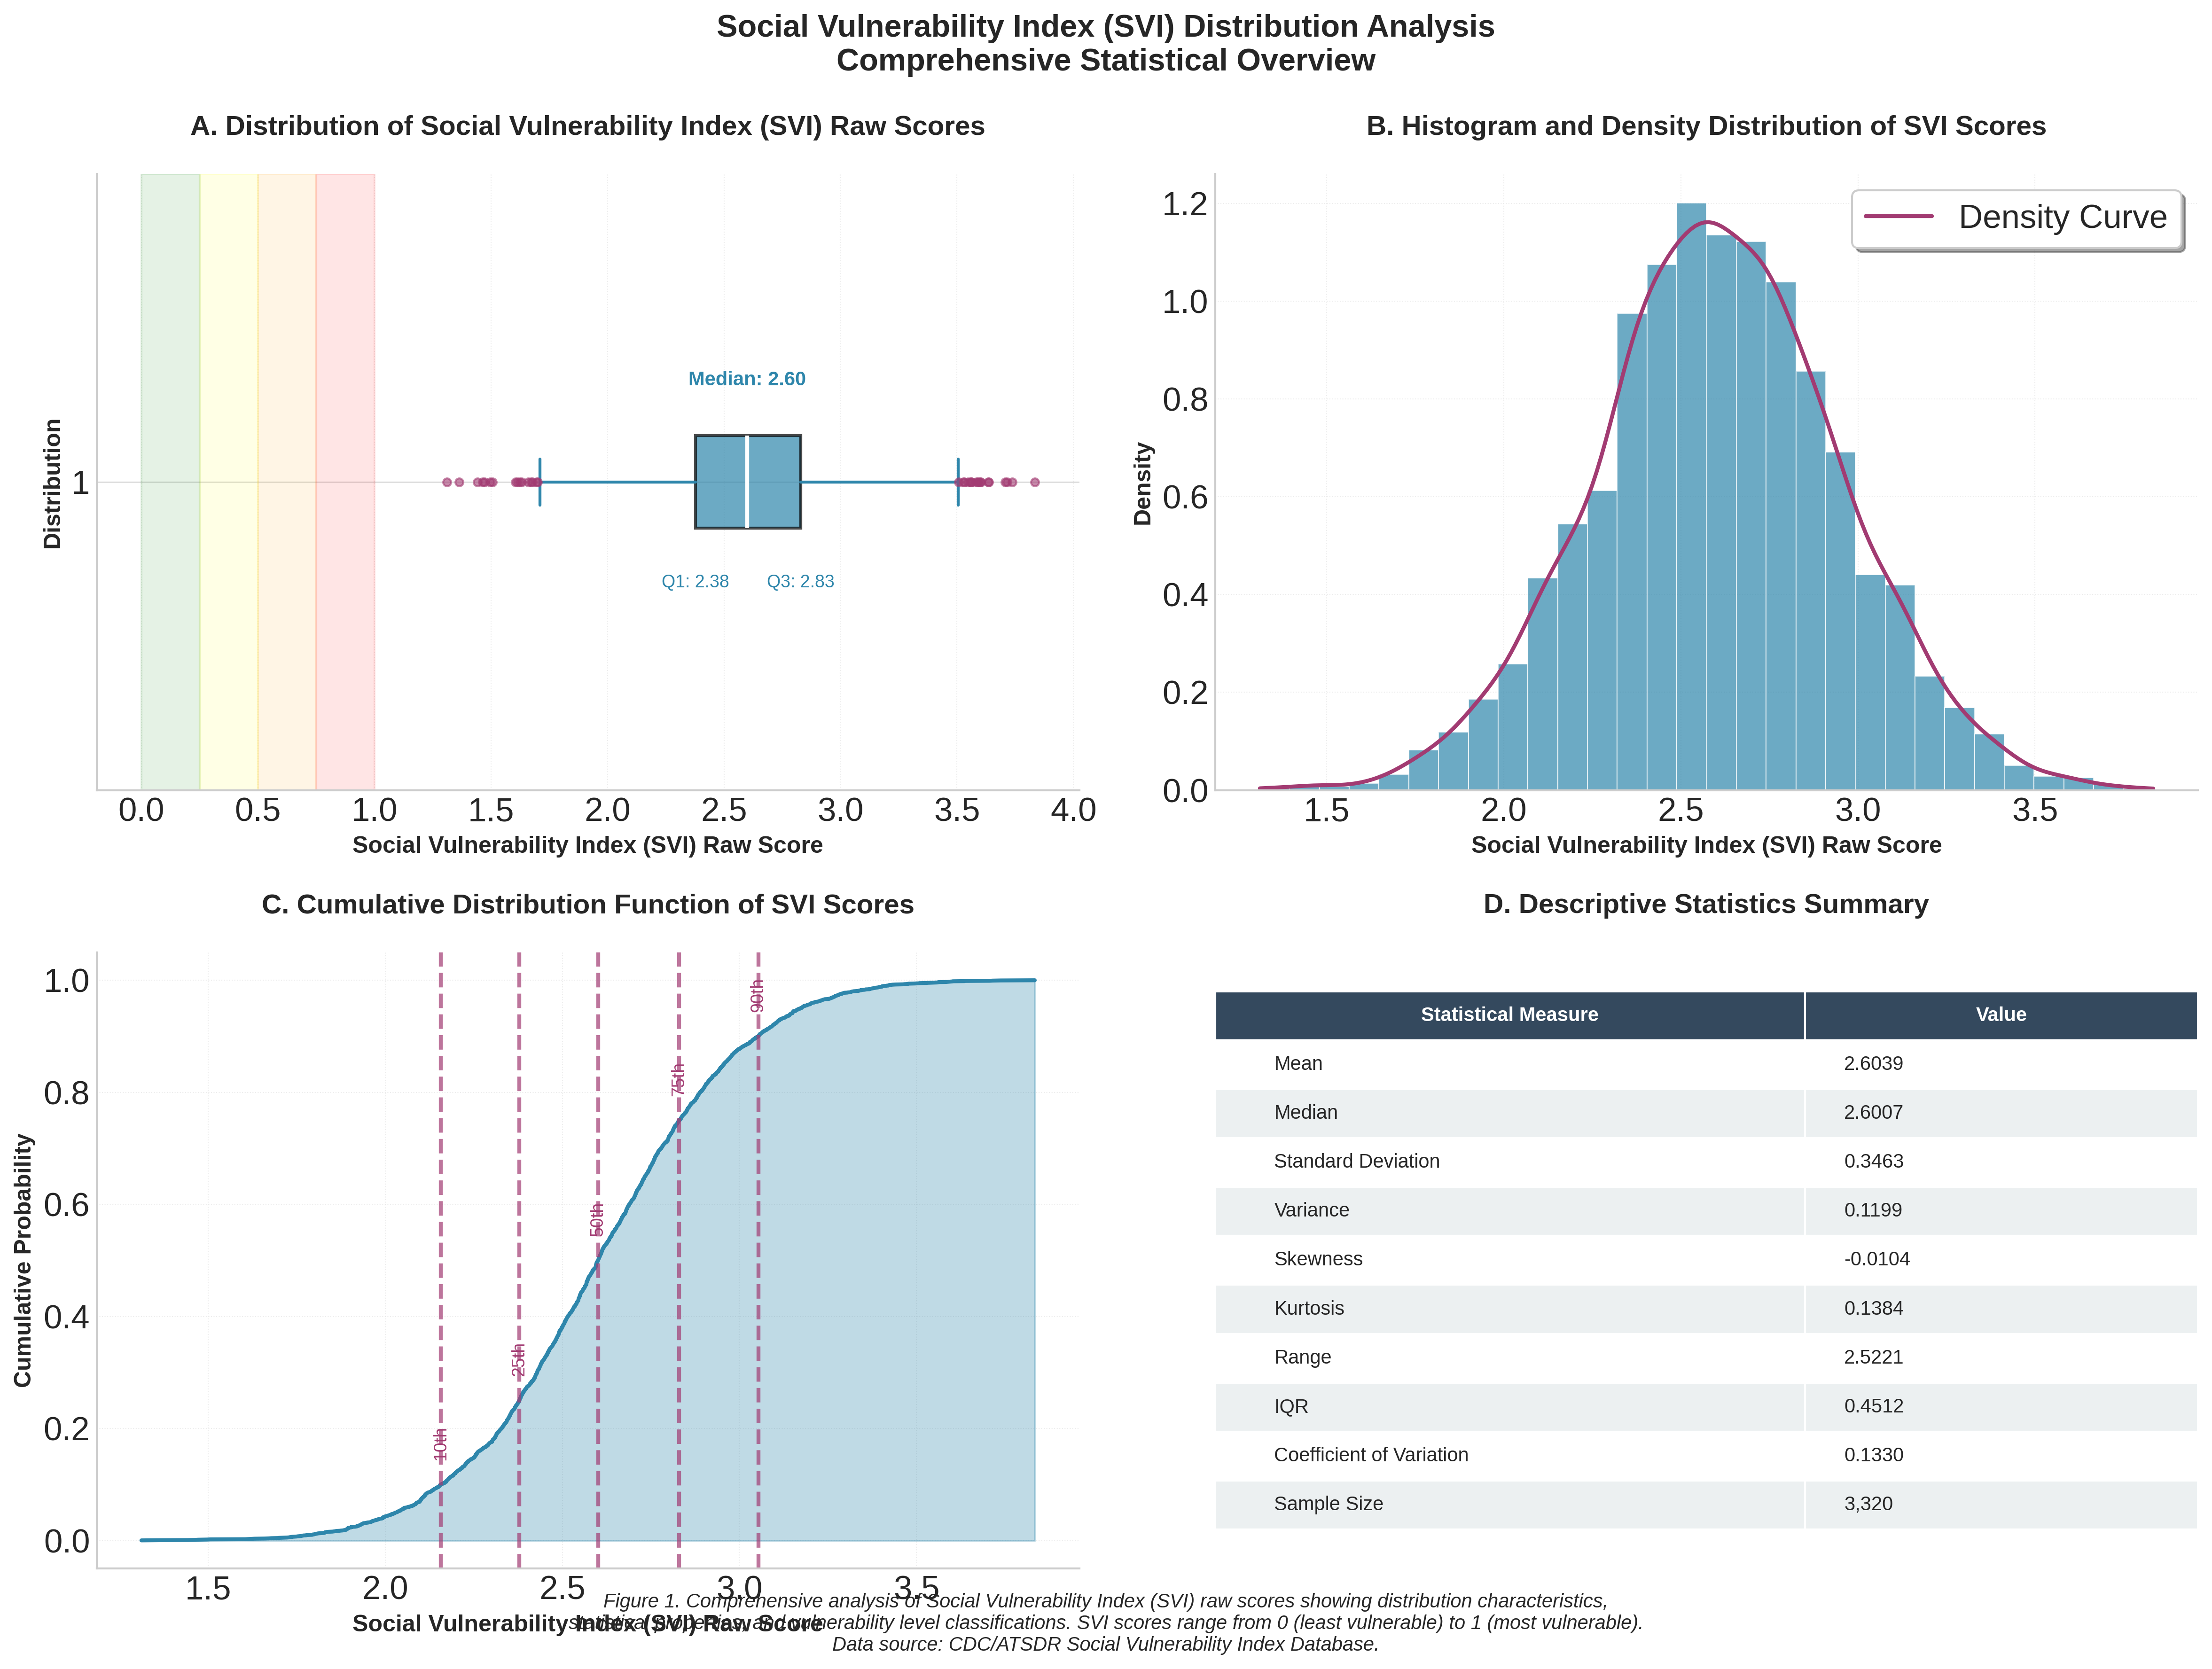

SOCIAL VULNERABILITY INDEX (SVI) ANALYSIS REPORT

EXECUTIVE SUMMARY:
• Dataset contains 3,320 observations of SVI raw scores
• Mean vulnerability score: 2.6039 (Scale: 0-1)
• Median vulnerability score: 2.6007
• Standard deviation: 0.3463

DISTRIBUTION CHARACTERISTICS:
• Skewness: -0.0104 (Approximately symmetric)
• Kurtosis: 0.1384 (Heavy-tailed)
• Coefficient of Variation: 0.1330 (Low variability)

VULNERABILITY LEVEL BREAKDOWN:
• Low Vulnerability (0.00-0.25): 0 areas (0.0%)
• Moderate Vulnerability (0.25-0.50): 0 areas (0.0%)
• High Vulnerability (0.50-0.75): 0 areas (0.0%)
• Very High Vulnerability (0.75-1.00): 3,320 areas (100.0%)

OUTLIER ANALYSIS:
• Number of outliers: 34 (1.02% of total)
• Outlier range: 1.3117 to 3.8338

POLICY IMPLICATIONS:
• 3,320 areas (100.0%) require immediate attention (SVI > 0.75)
• 3,320 areas (100.0%) show elevated vulnerability (SVI > 0.50)
• Geographic clustering analysis recommended for resource allocation
• Temporal trend analysis needed to asses

In [70]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set style for academic publication
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Create figure with subplots for comprehensive analysis
fig = plt.figure(figsize=(16, 12))

# Define colors for consistency
primary_color = '#2E86AB'
secondary_color = '#A23B72'
accent_color = '#F18F01'
grid_color = '#E5E5E5'

# Main boxplot (enhanced)
ax1 = plt.subplot(2, 2, 1)
s = are_correlated["SVI_raw"]

# Create boxplot with custom styling
box_plot = plt.boxplot(s, vert=False, patch_artist=True,
                       boxprops=dict(facecolor=primary_color, alpha=0.7, linewidth=1.5),
                       medianprops=dict(color='white', linewidth=2),
                       whiskerprops=dict(color=primary_color, linewidth=1.5),
                       capprops=dict(color=primary_color, linewidth=1.5),
                       flierprops=dict(marker='o', markerfacecolor=secondary_color,
                                       markeredgecolor=secondary_color, markersize=4, alpha=0.6))

# Add statistical annotations
q1, median, q3 = np.percentile(s, [25, 50, 75])
iqr = q3 - q1
lower_whisker = max(s.min(), q1 - 1.5 * iqr)
upper_whisker = min(s.max(), q3 + 1.5 * iqr)

# Add text annotations for key statistics
plt.text(median, 1.15, f'Median: {median:.2f}', ha='center', va='bottom',
         fontsize=10, fontweight='bold', color=primary_color)
plt.text(q1, 0.85, f'Q1: {q1:.2f}', ha='center', va='top', fontsize=9, color=primary_color)
plt.text(q3, 0.85, f'Q3: {q3:.2f}', ha='center', va='top', fontsize=9, color=primary_color)

plt.xlabel("Social Vulnerability Index (SVI) Raw Score", fontsize=12, fontweight='bold')
plt.ylabel("Distribution", fontsize=12, fontweight='bold')
plt.title("A. Distribution of Social Vulnerability Index (SVI) Raw Scores",
          fontsize=14, fontweight='bold', pad=20)
plt.grid(axis="x", linestyle=":", linewidth=0.5, color=grid_color, alpha=0.7)

# Add vulnerability level indicators
low_threshold = 0.25
moderate_threshold = 0.50
high_threshold = 0.75

# Color-coded background regions
ax1.axvspan(0, low_threshold, alpha=0.1, color='green', label='Low Vulnerability')
ax1.axvspan(low_threshold, moderate_threshold, alpha=0.1, color='yellow', label='Moderate Vulnerability')
ax1.axvspan(moderate_threshold, high_threshold, alpha=0.1, color='orange', label='High Vulnerability')
ax1.axvspan(high_threshold, 1, alpha=0.1, color='red', label='Very High Vulnerability')

# Histogram with density curve
ax2 = plt.subplot(2, 2, 2)
n, bins, patches = plt.hist(s, bins=30, alpha=0.7, color=primary_color,
                            edgecolor='white', linewidth=0.5, density=True)

# Add kernel density estimation
from scipy import stats

density = stats.gaussian_kde(s)
xs = np.linspace(s.min(), s.max(), 200)
plt.plot(xs, density(xs), color=secondary_color, linewidth=2, label='Density Curve')

plt.xlabel("Social Vulnerability Index (SVI) Raw Score", fontsize=12, fontweight='bold')
plt.ylabel("Density", fontsize=12, fontweight='bold')
plt.title("B. Histogram and Density Distribution of SVI Scores",
          fontsize=14, fontweight='bold', pad=20)
plt.legend(frameon=True, fancybox=True, shadow=True)
plt.grid(axis="both", linestyle=":", linewidth=0.5, color=grid_color, alpha=0.7)

# Cumulative distribution
ax3 = plt.subplot(2, 2, 3)
sorted_data = np.sort(s)
cumulative = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
plt.plot(sorted_data, cumulative, color=primary_color, linewidth=2)
plt.fill_between(sorted_data, cumulative, alpha=0.3, color=primary_color)

# Add percentile markers
percentiles = [10, 25, 50, 75, 90]
for p in percentiles:
    value = np.percentile(s, p)
    plt.axvline(value, color=secondary_color, linestyle='--', alpha=0.7)
    plt.text(value, p / 100 + 0.05, f'{p}th', rotation=90, ha='center',
             fontsize=9, color=secondary_color)

plt.xlabel("Social Vulnerability Index (SVI) Raw Score", fontsize=12, fontweight='bold')
plt.ylabel("Cumulative Probability", fontsize=12, fontweight='bold')
plt.title("C. Cumulative Distribution Function of SVI Scores",
          fontsize=14, fontweight='bold', pad=20)
plt.grid(True, linestyle=":", linewidth=0.5, color=grid_color, alpha=0.7)

# Summary statistics table
ax4 = plt.subplot(2, 2, 4)
ax4.axis('off')

# Calculate comprehensive statistics
stats_data = {
    'Statistic': ['Mean', 'Median', 'Standard Deviation', 'Variance', 'Skewness',
                  'Kurtosis', 'Range', 'IQR', 'Coefficient of Variation', 'Sample Size'],
    'Value': [f'{s.mean():.4f}', f'{median:.4f}', f'{s.std():.4f}',
              f'{s.var():.4f}', f'{stats.skew(s):.4f}', f'{stats.kurtosis(s):.4f}',
              f'{s.max() - s.min():.4f}', f'{iqr:.4f}',
              f'{s.std() / s.mean():.4f}', f'{len(s):,}']
}

# Create table
table = ax4.table(cellText=[[stat, val] for stat, val in zip(stats_data['Statistic'], stats_data['Value'])],
                  colLabels=['Statistical Measure', 'Value'],
                  cellLoc='left',
                  loc='center',
                  colWidths=[0.6, 0.4])

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# Style the table
for i in range(len(stats_data['Statistic']) + 1):
    for j in range(2):
        cell = table[(i, j)]
        if i == 0:  # Header row
            cell.set_facecolor('#34495e')
            cell.set_text_props(weight='bold', color='white')
        else:
            cell.set_facecolor('#ecf0f1' if i % 2 == 0 else 'white')
        cell.set_edgecolor('white')
        cell.set_linewidth(1)

ax4.set_title("D. Descriptive Statistics Summary", fontsize=14, fontweight='bold', pad=20)
savefig_standard("plots/svi_analysis/major statistic 2.png")

# Overall figure title and layout
fig.suptitle('Social Vulnerability Index (SVI) Distribution Analysis\nComprehensive Statistical Overview',
             fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Add figure caption/note
fig.text(0.5, 0.01,
         'Figure 1. Comprehensive analysis of Social Vulnerability Index (SVI) raw scores showing distribution characteristics,\n'
         'statistical properties, and vulnerability level classifications. SVI scores range from 0 (least vulnerable) to 1 (most vulnerable).\n'
         'Data source: CDC/ATSDR Social Vulnerability Index Database.',
         ha='center', va='bottom', fontsize=10, style='italic', wrap=True)

savefig_standard("plots/svi_analysis/major statistic.png")
plt.show()

# Additional analysis and interpretation
print("=" * 80)
print("SOCIAL VULNERABILITY INDEX (SVI) ANALYSIS REPORT")
print("=" * 80)
print()

print("EXECUTIVE SUMMARY:")
print(f"• Dataset contains {len(s):,} observations of SVI raw scores")
print(f"• Mean vulnerability score: {s.mean():.4f} (Scale: 0-1)")
print(f"• Median vulnerability score: {median:.4f}")
print(f"• Standard deviation: {s.std():.4f}")
print()

print("DISTRIBUTION CHARACTERISTICS:")
skewness = stats.skew(s)
kurtosis_val = stats.kurtosis(s)
print(
    f"• Skewness: {skewness:.4f} ({'Right-skewed' if skewness > 0.5 else 'Left-skewed' if skewness < -0.5 else 'Approximately symmetric'})")
print(f"• Kurtosis: {kurtosis_val:.4f} ({'Heavy-tailed' if kurtosis_val > 0 else 'Light-tailed'})")
print(
    f"• Coefficient of Variation: {s.std() / s.mean():.4f} ({'High variability' if s.std() / s.mean() > 0.3 else 'Moderate variability' if s.std() / s.mean() > 0.15 else 'Low variability'})")
print()

print("VULNERABILITY LEVEL BREAKDOWN:")
low_vuln = (s <= 0.25).sum()
moderate_vuln = ((s > 0.25) & (s <= 0.50)).sum()
high_vuln = ((s > 0.50) & (s <= 0.75)).sum()
very_high_vuln = (s > 0.75).sum()

print(f"• Low Vulnerability (0.00-0.25): {low_vuln:,} areas ({low_vuln / len(s) * 100:.1f}%)")
print(f"• Moderate Vulnerability (0.25-0.50): {moderate_vuln:,} areas ({moderate_vuln / len(s) * 100:.1f}%)")
print(f"• High Vulnerability (0.50-0.75): {high_vuln:,} areas ({high_vuln / len(s) * 100:.1f}%)")
print(f"• Very High Vulnerability (0.75-1.00): {very_high_vuln:,} areas ({very_high_vuln / len(s) * 100:.1f}%)")
print()

print("OUTLIER ANALYSIS:")
outliers = s.filter((s < lower_whisker) | (s > upper_whisker))
print(f"• Number of outliers: {len(outliers):,} ({len(outliers) / len(s) * 100:.2f}% of total)")
print(f"• Outlier range: {outliers.min():.4f} to {outliers.max():.4f}")
print()

print("POLICY IMPLICATIONS:")
high_priority_areas = (s > 0.75).sum()
print(
    f"• {high_priority_areas:,} areas ({high_priority_areas / len(s) * 100:.1f}%) require immediate attention (SVI > 0.75)")
print(f"• {(s > 0.50).sum():,} areas ({(s > 0.50).sum() / len(s) * 100:.1f}%) show elevated vulnerability (SVI > 0.50)")
print("• Geographic clustering analysis recommended for resource allocation")
print("• Temporal trend analysis needed to assess vulnerability changes over time")

In [47]:

from scipy import stats
from typing import Sequence


def create_and_save_svi_stats_table(data: Sequence,
                                    save_path: str = "plots/svi_analysis/major_statistic_table.png", ):
    """
    Create a descriptive statistics table for SVI-like data and save it using plt.savefig.

    Parameters
    ----------
    data : Sequence
        Array-like (Polars Series, pandas Series, numpy array, list) of numeric SVI values.
    save_path : str
        File path to save the table image. Directory will be created if missing.
    figsize : tuple
        Figure size for the table image.
    fontsize : int
        Base font size for the table text.
    """

    # --- prepare output directory
    out_dir = os.path.dirname(save_path)
    if out_dir:
        os.makedirs(out_dir, exist_ok=True)

    # --- convert to numpy array and clean
    arr = np.asarray(data)
    # Polars Series can be passed directly; ensure flattening
    try:
        arr = arr.ravel()
    except Exception:
        arr = np.asarray(arr)

    arr = arr[np.isfinite(arr)]  # drop NaN / +/-inf

    if arr.size == 0:
        raise ValueError("Input `data` contains no finite values after cleaning.")

    # --- compute statistics
    mean_val = arr.mean()
    median_val = np.median(arr)
    std_val = arr.std(ddof=1)
    var_val = arr.var(ddof=1)
    skew_val = float(stats.skew(arr))
    kurtosis_val = float(stats.kurtosis(arr))
    range_val = arr.max() - arr.min()
    q1, q3 = np.percentile(arr, [25, 75])
    iqr = q3 - q1
    coeff_var = std_val / mean_val if mean_val != 0 else np.nan
    sample_size = arr.size

    # whisker-based outlier boundaries (Tukey)
    lower_whisker = max(arr.min(), q1 - 1.5 * iqr)
    upper_whisker = min(arr.max(), q3 + 1.5 * iqr)
    outlier_mask = (arr < lower_whisker) | (arr > upper_whisker)
    n_outliers = int(np.sum(outlier_mask))

    # --- prepare table rows
    rows = [
        ("Mean", f"{mean_val:.4f}"),
        ("Median", f"{median_val:.4f}"),
        ("Standard Deviation", f"{std_val:.4f}"),
        ("Variance", f"{var_val:.4f}"),
        ("Skewness", f"{skew_val:.4f}"),
        ("Kurtosis", f"{kurtosis_val:.4f}"),
        ("Range", f"{range_val:.4f}"),
        ("IQR", f"{iqr:.4f}"),
        ("Coefficient of Variation", f"{coeff_var:.4f}" if not np.isnan(coeff_var) else "NaN"),
        ("Sample Size", f"{sample_size:,}"),
        ("Lower whisker (Tukey)", f"{lower_whisker:.4f}"),
        ("Upper whisker (Tukey)", f"{upper_whisker:.4f}"),
        ("Number of outliers (Tukey)", f"{n_outliers:,}")
    ]

    # --- draw table
    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.axis("off")

    # Build the table (body only via cellText; header via colLabels)
    cell_text = [[r, v] for r, v in rows]
    table = ax.table(cellText=cell_text,
                     colLabels=["Statistical Measure", "Value"],
                     cellLoc="left",
                     colLoc="left",
                     loc="center")

    # scale table to fill axes nicely
    table.scale(1, 1.6)

    # Style cells explicitly (header + alternating rows)
    for (row, col), cell in table.get_celld().items():
        # row == 0 is the header when colLabels is used
        if row == 0:
            cell.set_facecolor("#34495e")
            cell.get_text().set_color("white")
            cell.get_text().set_weight("bold")
        else:
            # alternate row background for readability
            if row % 2 == 0:
                cell.set_facecolor("#ecf0f1")
            else:
                cell.set_facecolor("white")
        cell.set_edgecolor("white")
        cell.set_linewidth(1)

    ax.set_title("Descriptive Statistics Summary", fontweight="bold", pad=12)

    # --- save safely
    savefig_standard(save_path)
    plt.close(fig)

    return save_path


# Example usage:
# If 'are_correlated' is a Polars DataFrame and 'SVI_raw' is the column:

path = create_and_save_svi_stats_table(are_correlated["SVI_raw"],
                                       save_path="plots/svi_analysis/major_statistic_table.png")
# print("Saved table to:", path)


Saved: plots/svi_analysis/major_statistic_table.png


Saved: plots/svi_analysis/svi_empirical_cdf_extracted.png


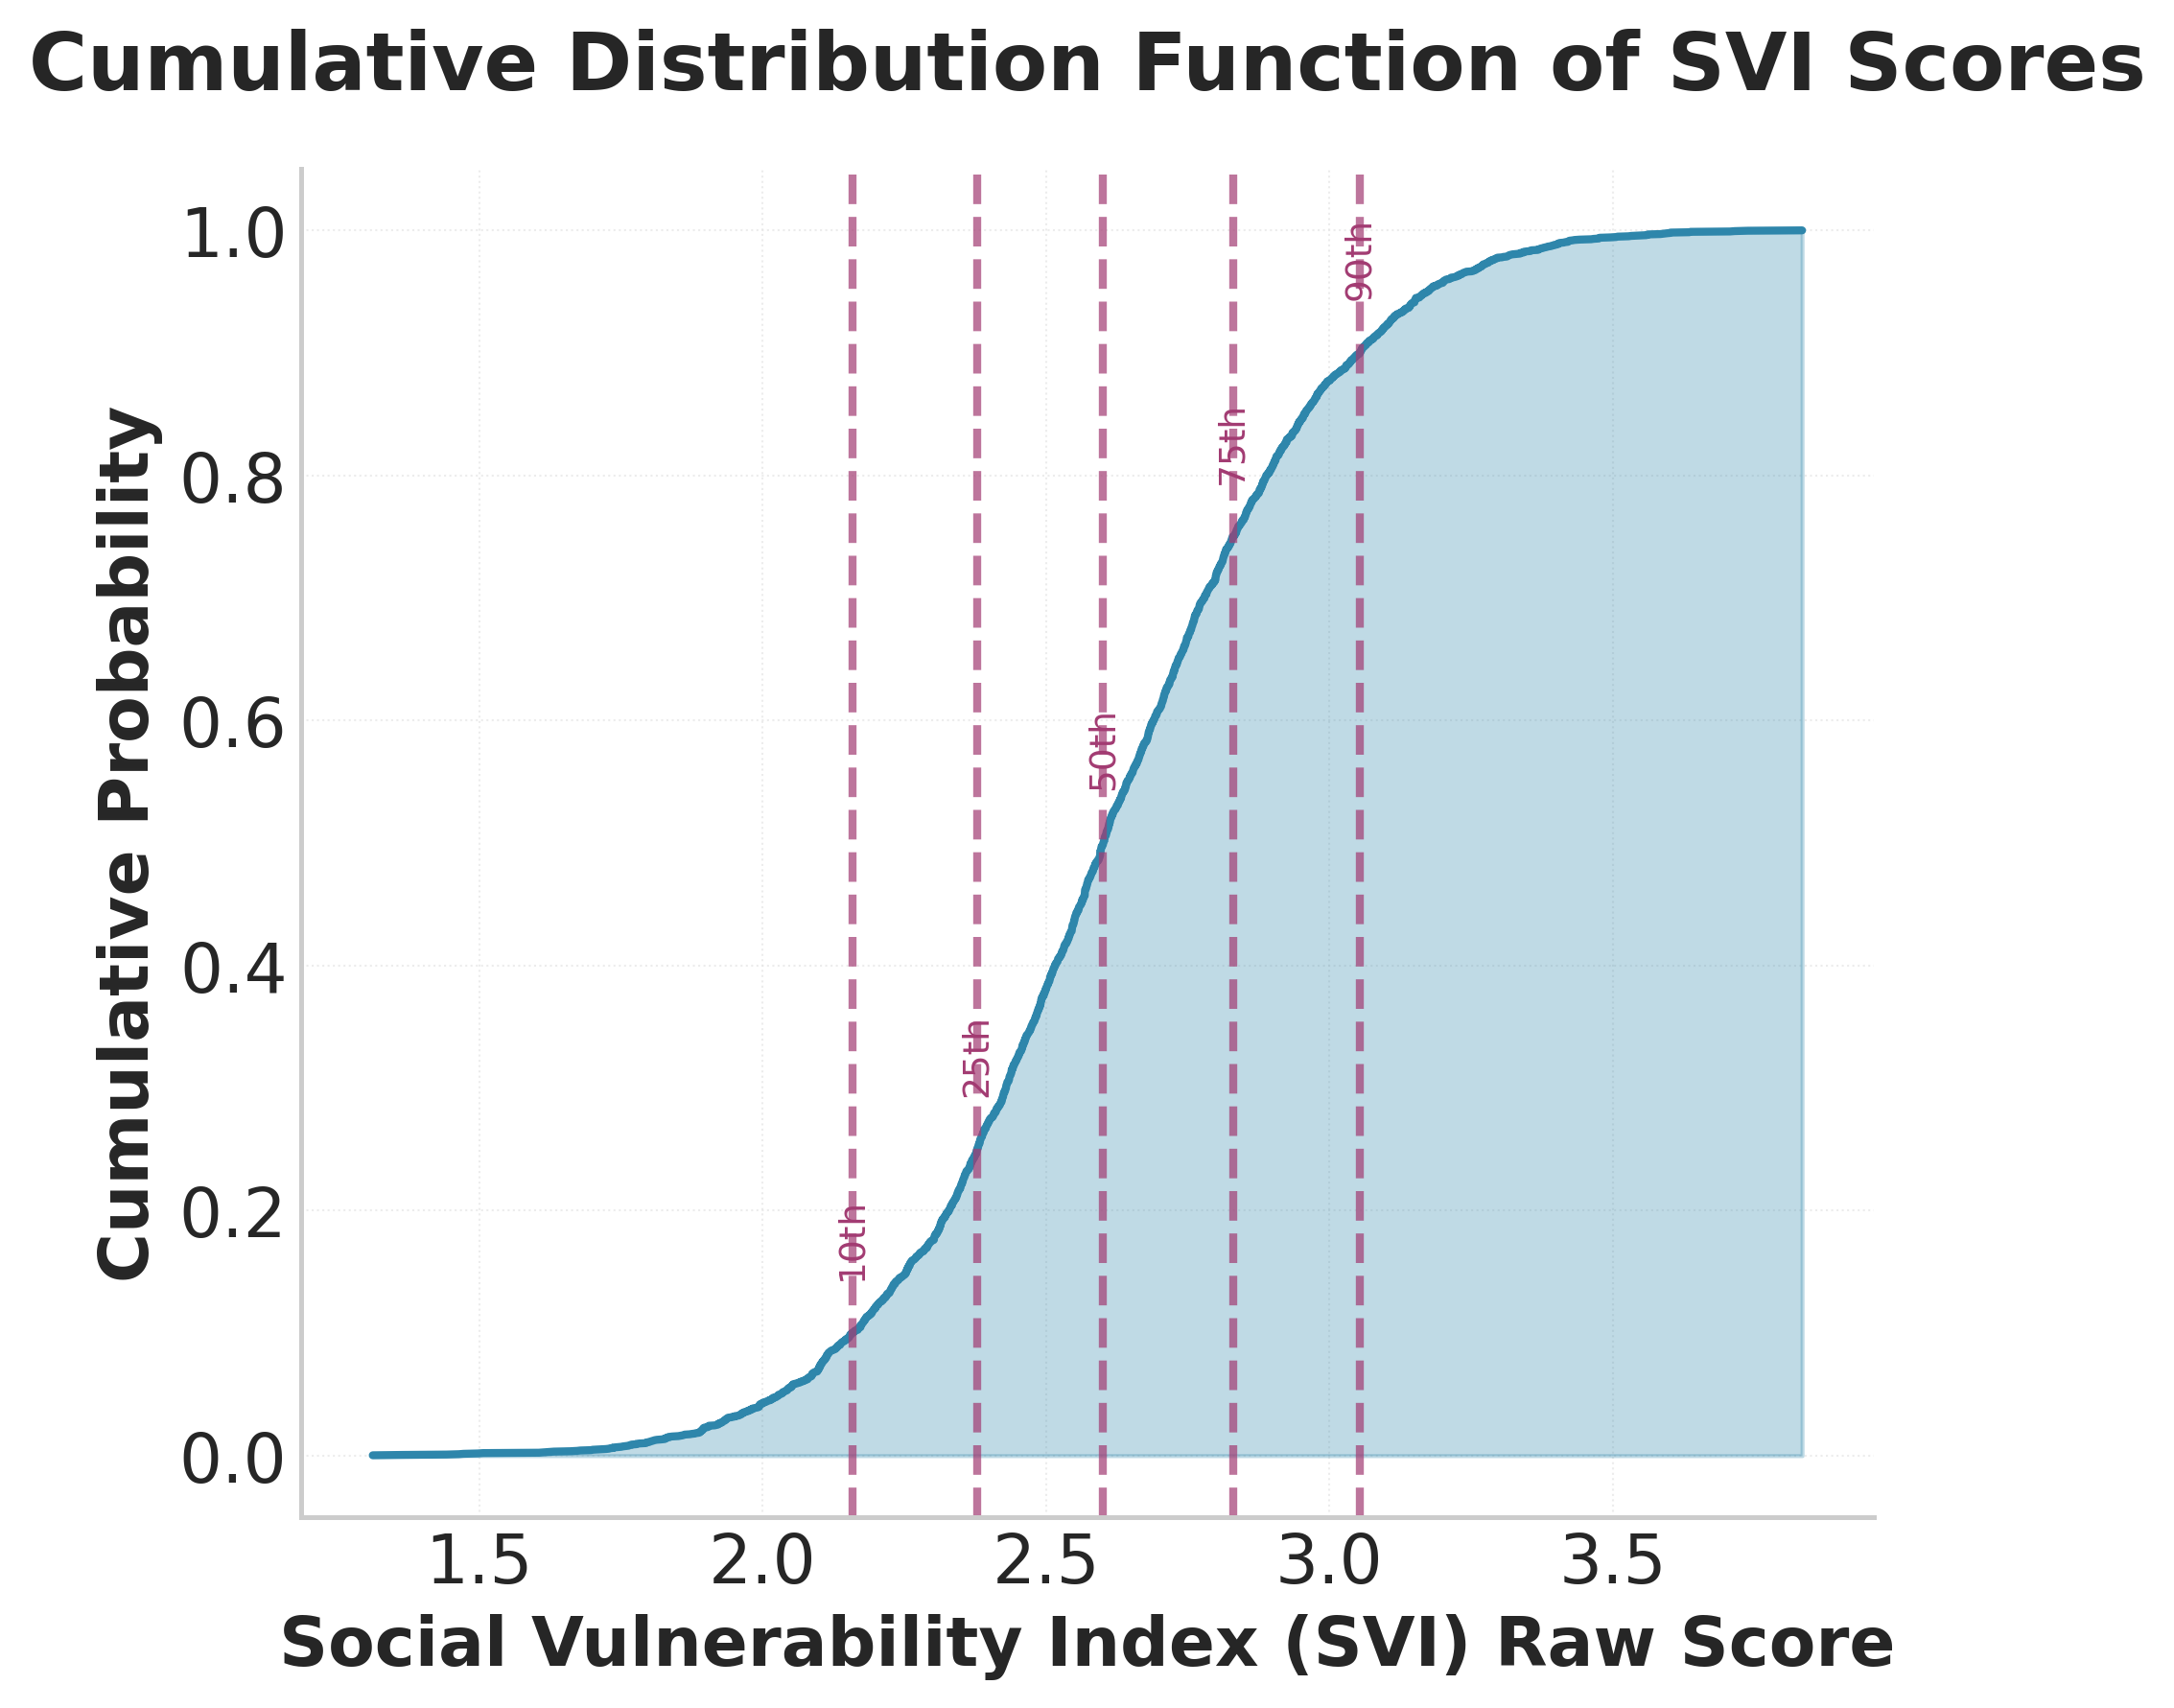

In [49]:
import matplotlib.pyplot as plt
import numpy as np

# --- Cumulative distribution (extracted)
fig, ax = plt.subplots()
s = np.array(are_correlated["SVI_raw"])
sorted_data = np.sort(s)
cumulative = np.arange(1, len(sorted_data) + 1) / len(sorted_data)

ax.plot(sorted_data, cumulative, color=primary_color, linewidth=2)
ax.fill_between(sorted_data, cumulative, alpha=0.3, color=primary_color)

# Add percentile markers (same as original)
percentiles = [10, 25, 50, 75, 90]
for p in percentiles:
    value = np.percentile(s, p)
    ax.axvline(value, color=secondary_color, linestyle='--', alpha=0.7)
    ax.text(value, p / 100 + 0.05, f'{p}th', rotation=90, ha='center',
            fontsize=9, color=secondary_color)

ax.set_xlabel("Social Vulnerability Index (SVI) Raw Score", fontweight='bold')
ax.set_ylabel("Cumulative Probability", fontweight='bold')
ax.set_title("Cumulative Distribution Function of SVI Scores",
             fontweight='bold', pad=20)
ax.grid(True, linestyle=":", linewidth=0.5, color=grid_color, alpha=0.7)

# Save using your safe save helper (keeps original behavior)
savefig_standard("plots/svi_analysis/svi_empirical_cdf_extracted.png")

# now `fig` and `ax` are available for downstream use
plt.show()


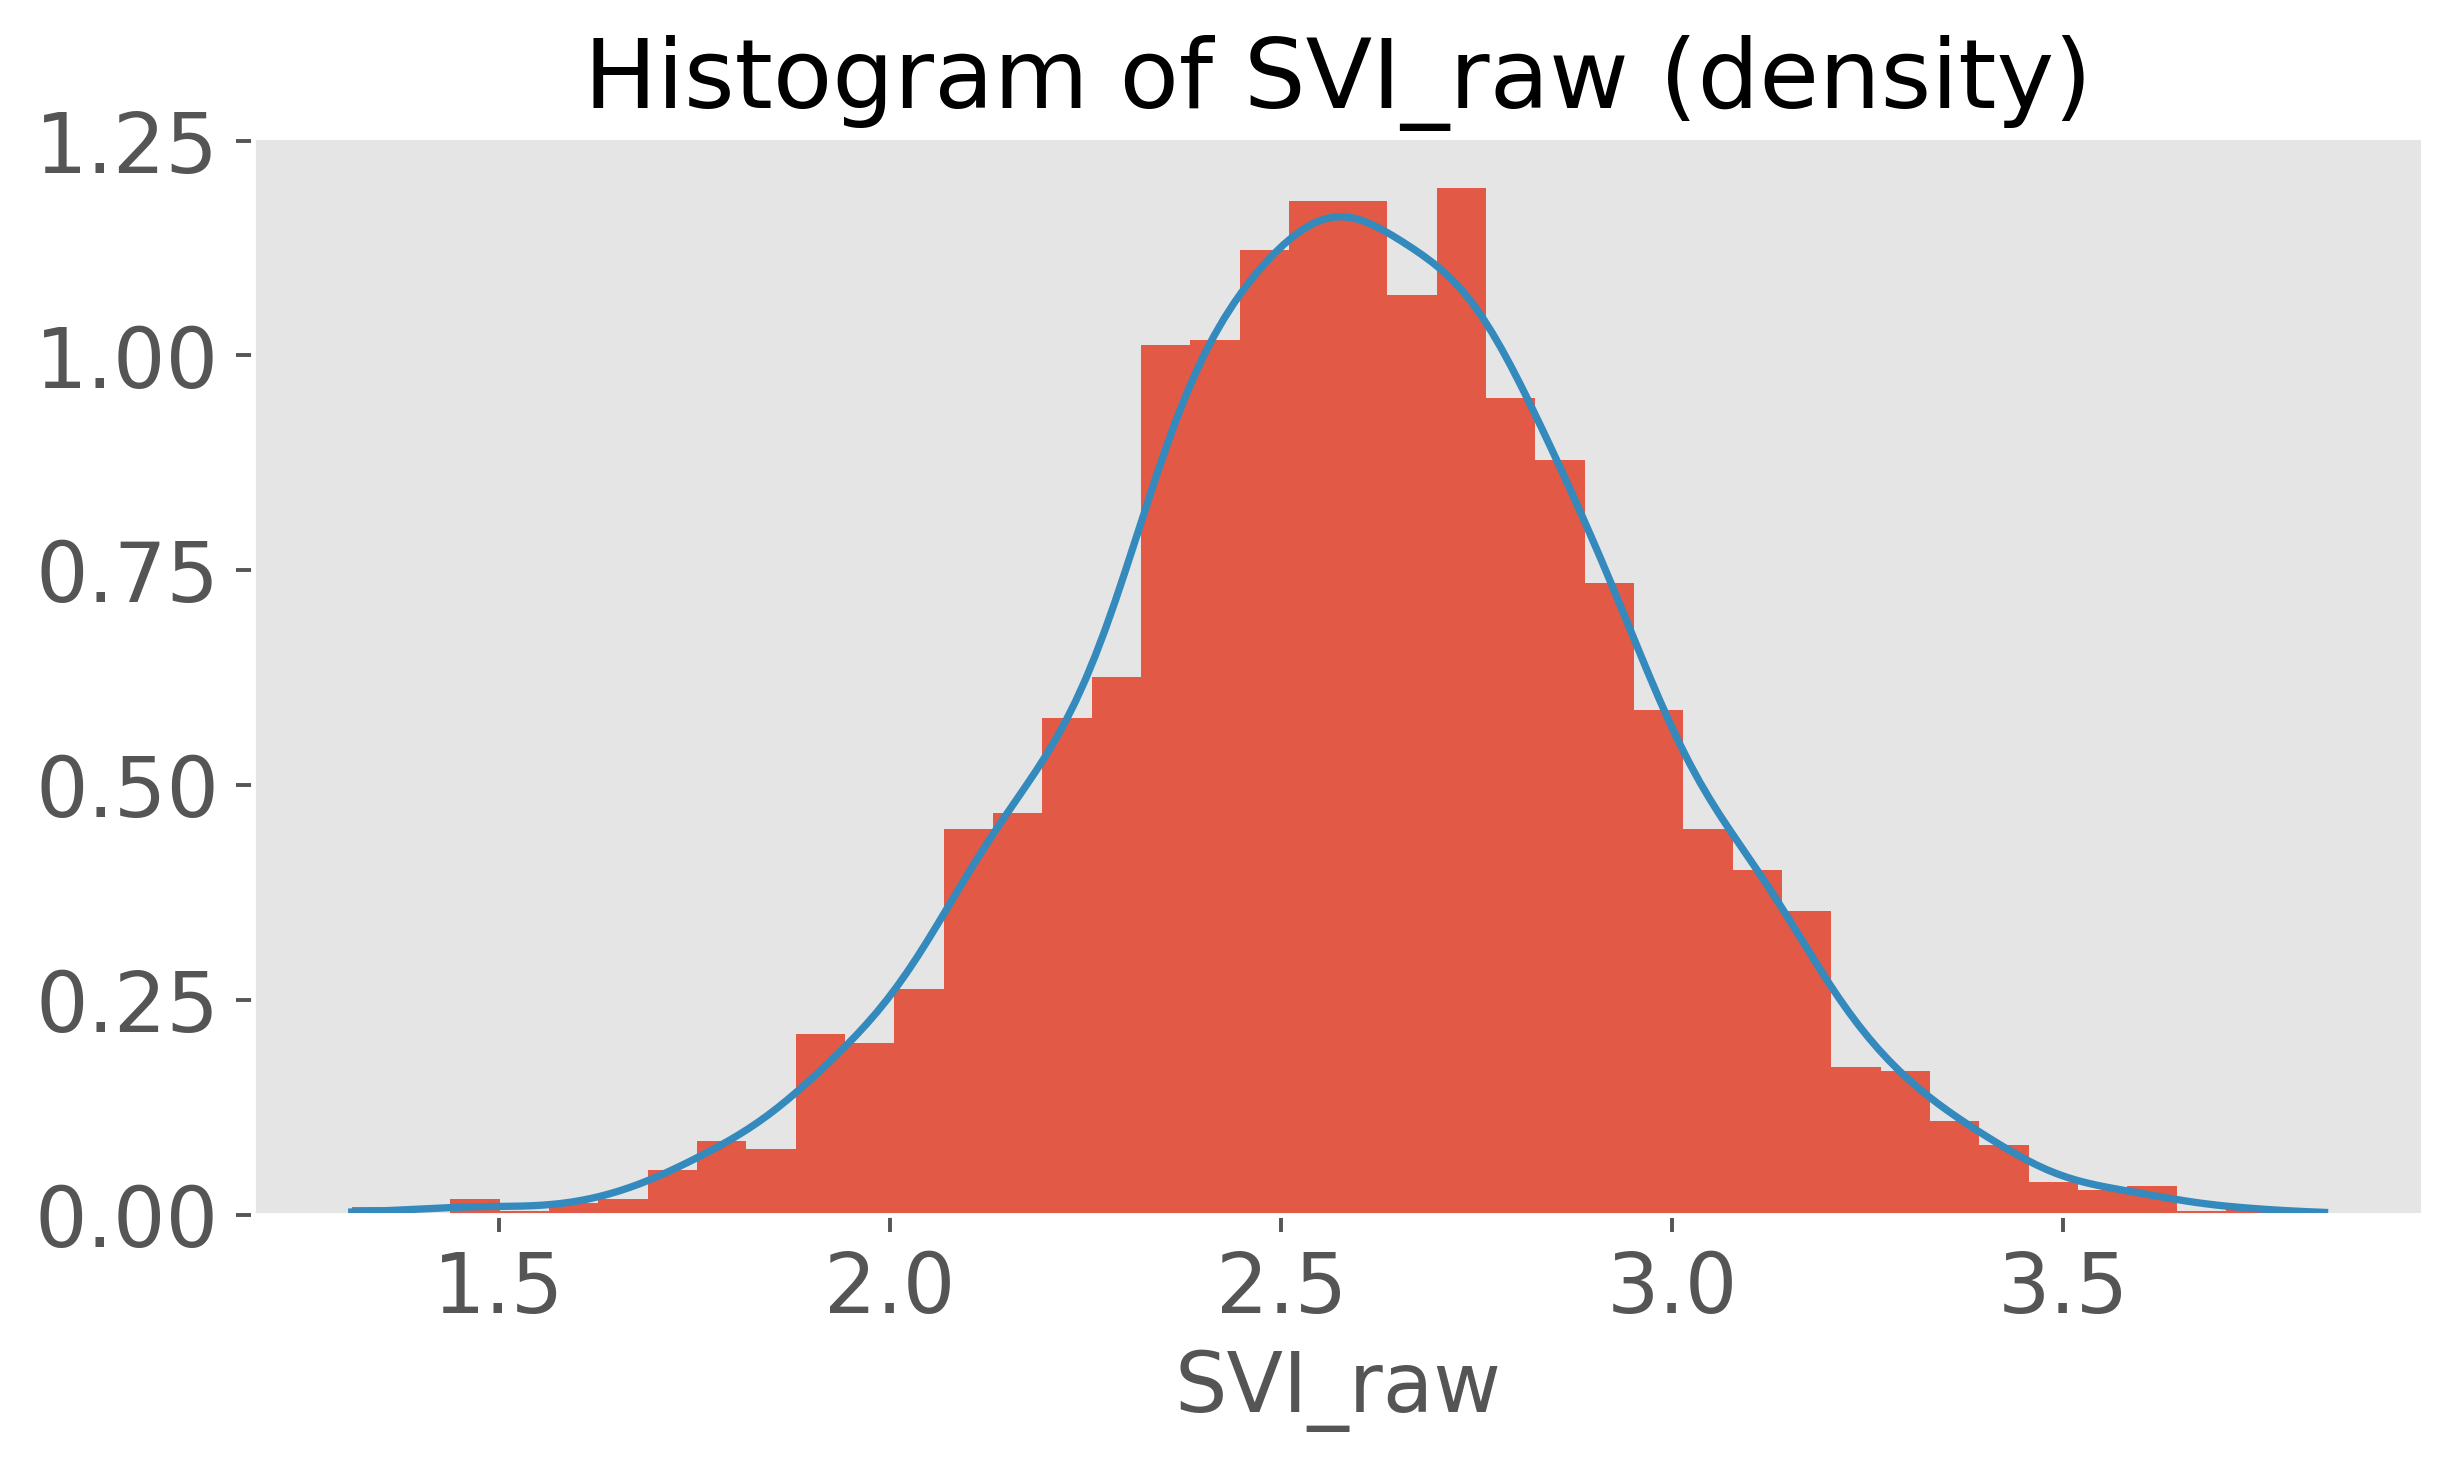

In [44]:

plt.figure(figsize=(8, 4))
plt.hist(s, bins=40, density=True, alpha=0.9)
# optional KDE using scipy if available:
try:
    from scipy.stats import gaussian_kde

    kde = gaussian_kde(s)
    xs = np.linspace(s.min(), s.max(), 200)
    plt.plot(xs, kde(xs))
except Exception:
    # fallback: overlay normal approx
    mu, sigma = s.mean(), s.std(ddof=1)
    xs = np.linspace(s.min(), s.max(), 200)
    plt.plot(xs, 1 / (sigma * np.sqrt(2 * np.pi)) * np.exp(-0.5 * ((xs - mu) / sigma) ** 2), linestyle="--")
plt.xlabel("SVI_raw")
plt.title("Histogram of SVI_raw (density)")
plt.show()



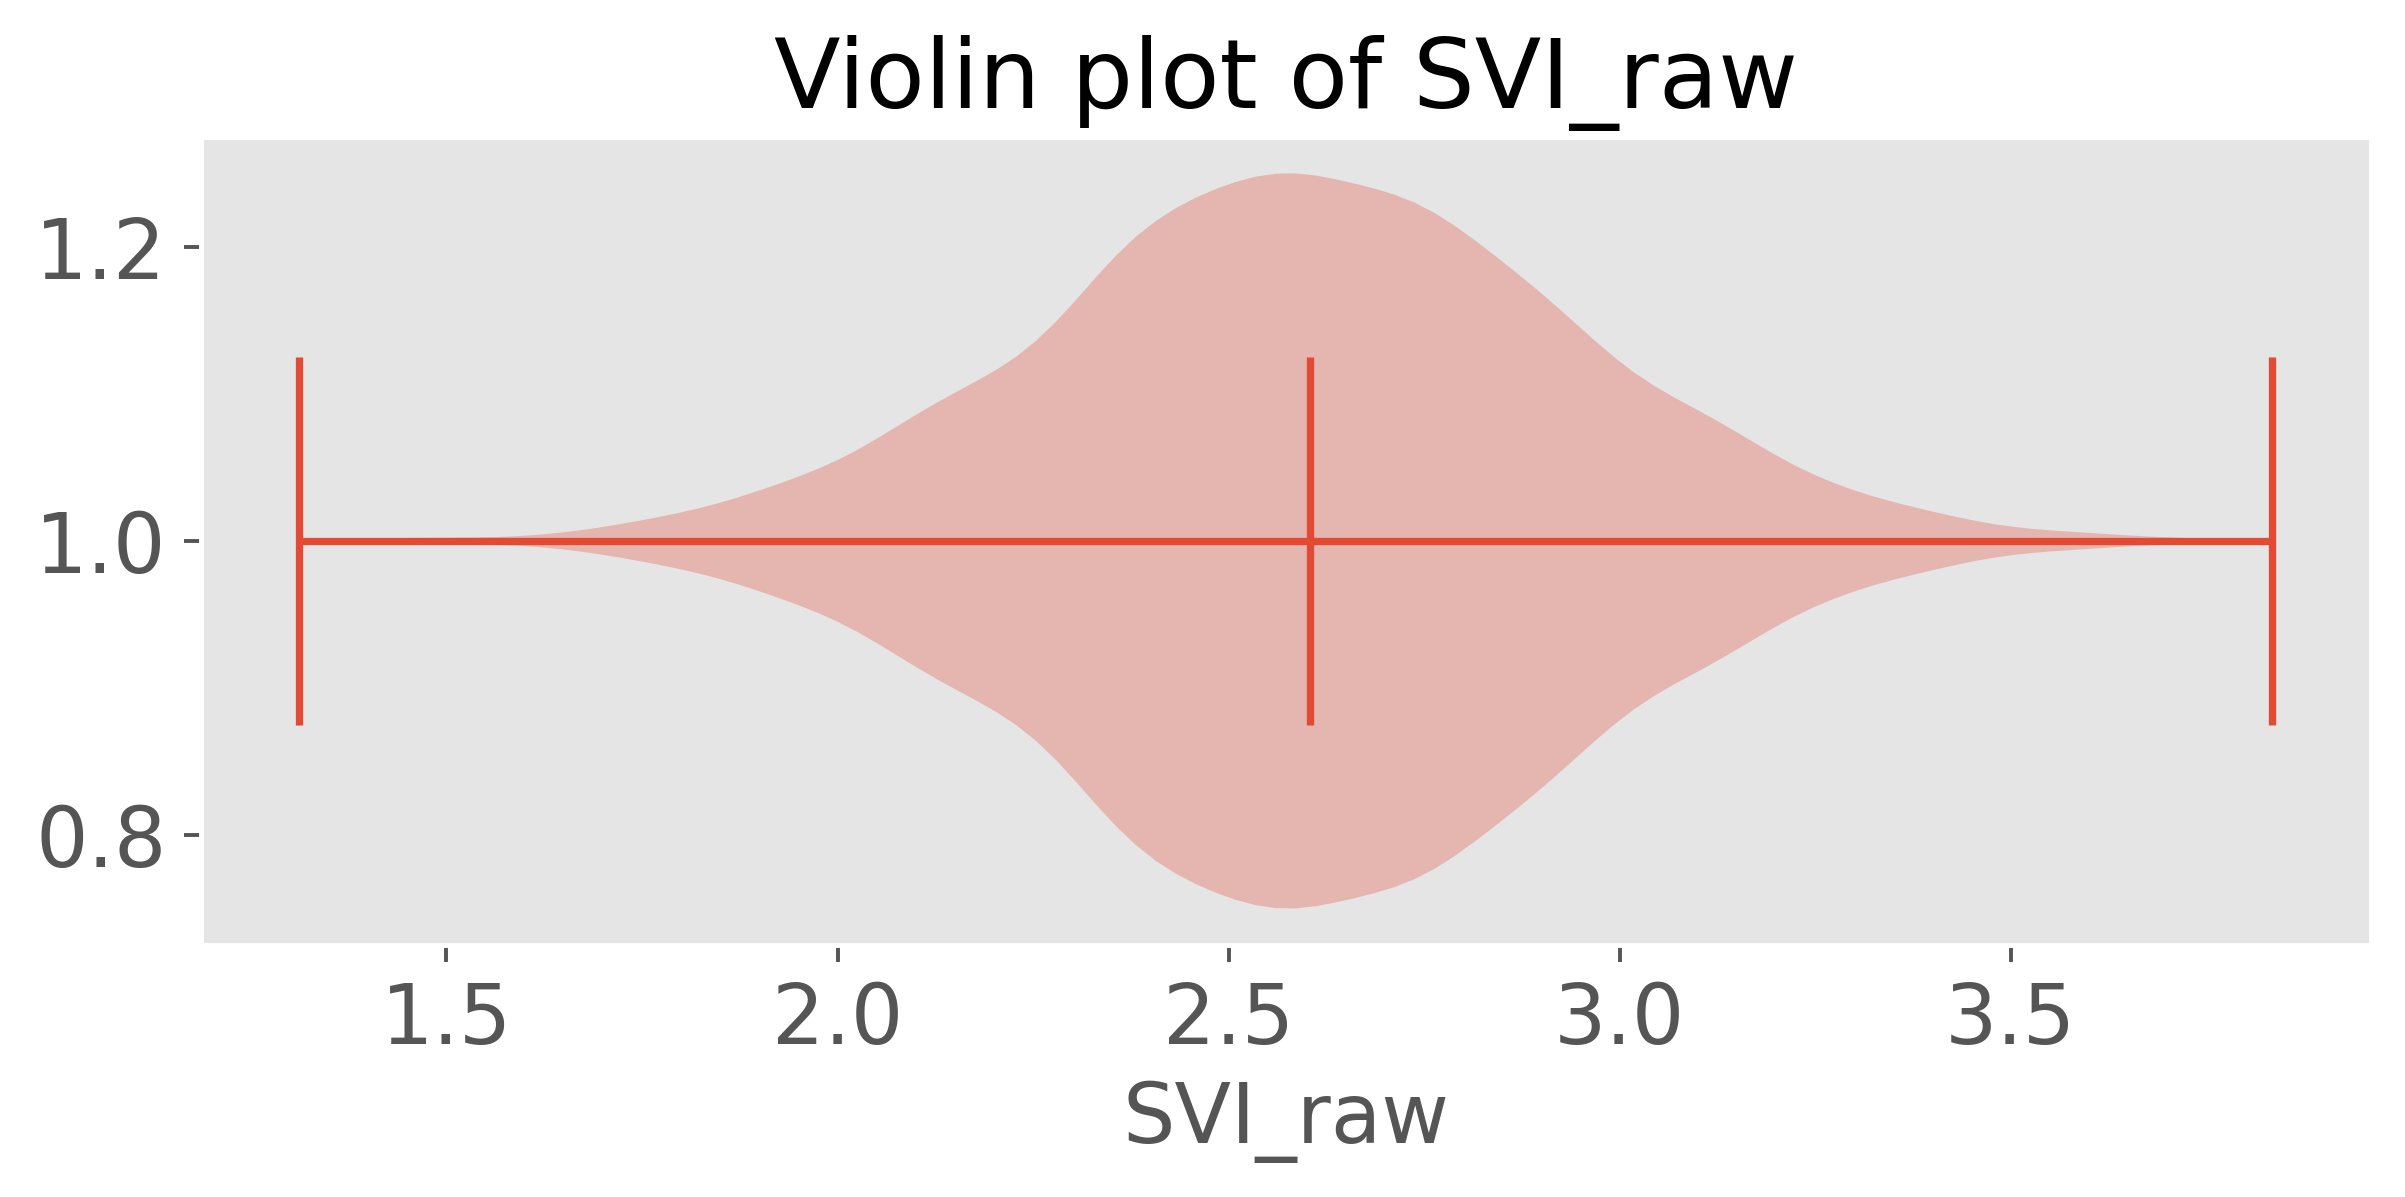

In [47]:
plt.figure(figsize=(8, 3))
plt.violinplot(s, vert=False, showmeans=True)
plt.xlabel("SVI_raw")
plt.title("Violin plot of SVI_raw")
plt.show()


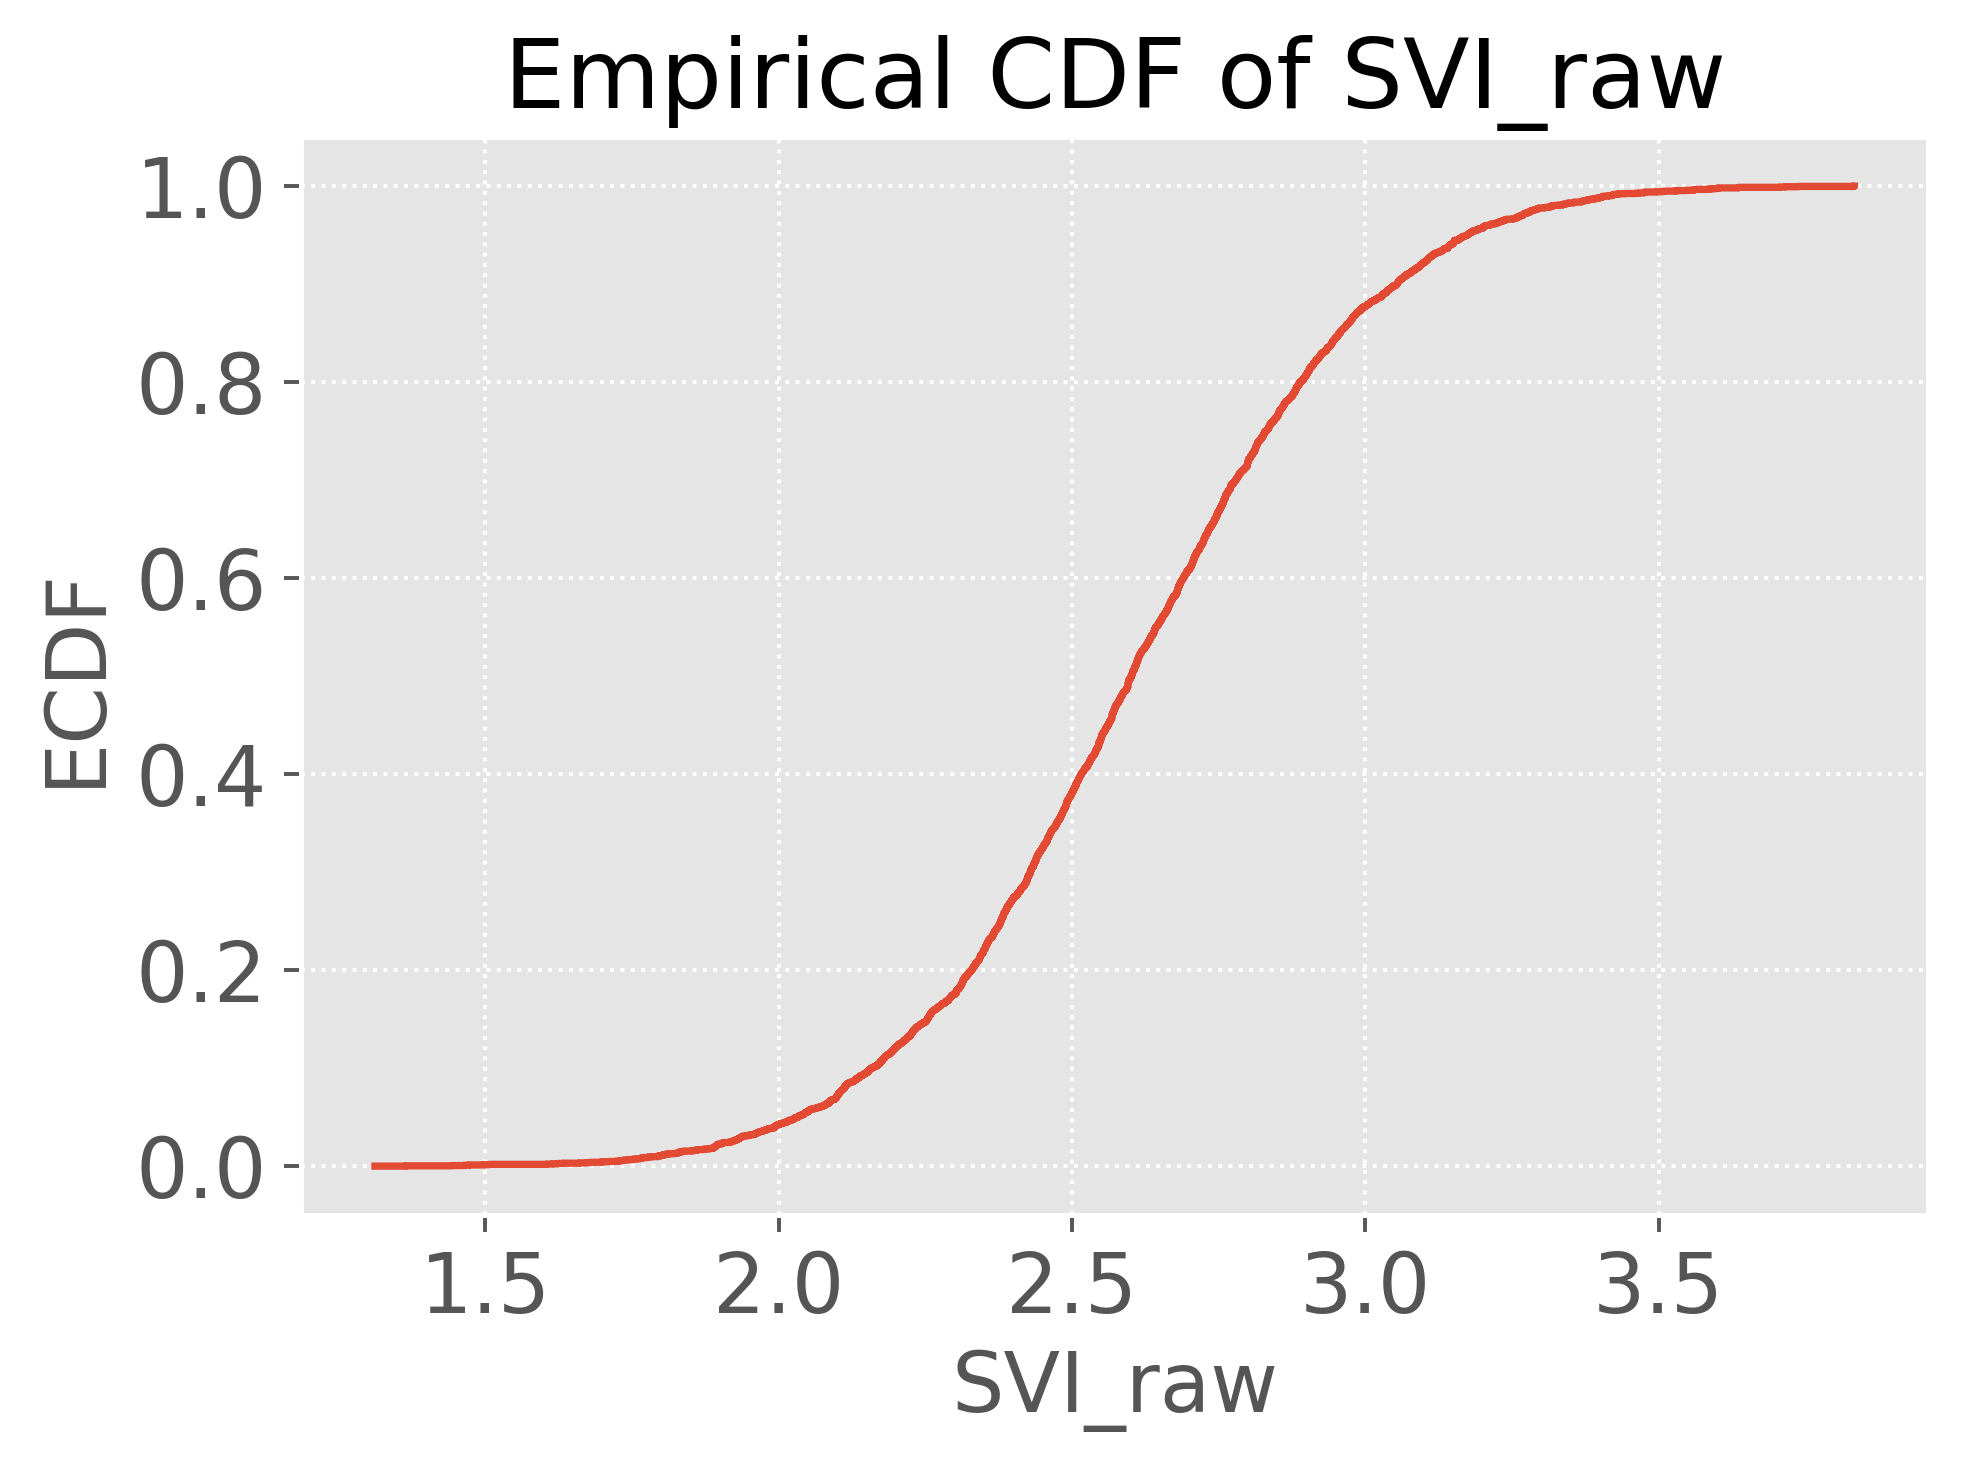

In [48]:
vals = np.sort(s)
p = np.arange(1, len(vals) + 1) / len(vals)
plt.figure(figsize=(6, 4))
plt.step(vals, p, where="post")
plt.xlabel("SVI_raw")
plt.ylabel("ECDF")
plt.title("Empirical CDF of SVI_raw")
plt.grid(True, linestyle=":")
plt.show()


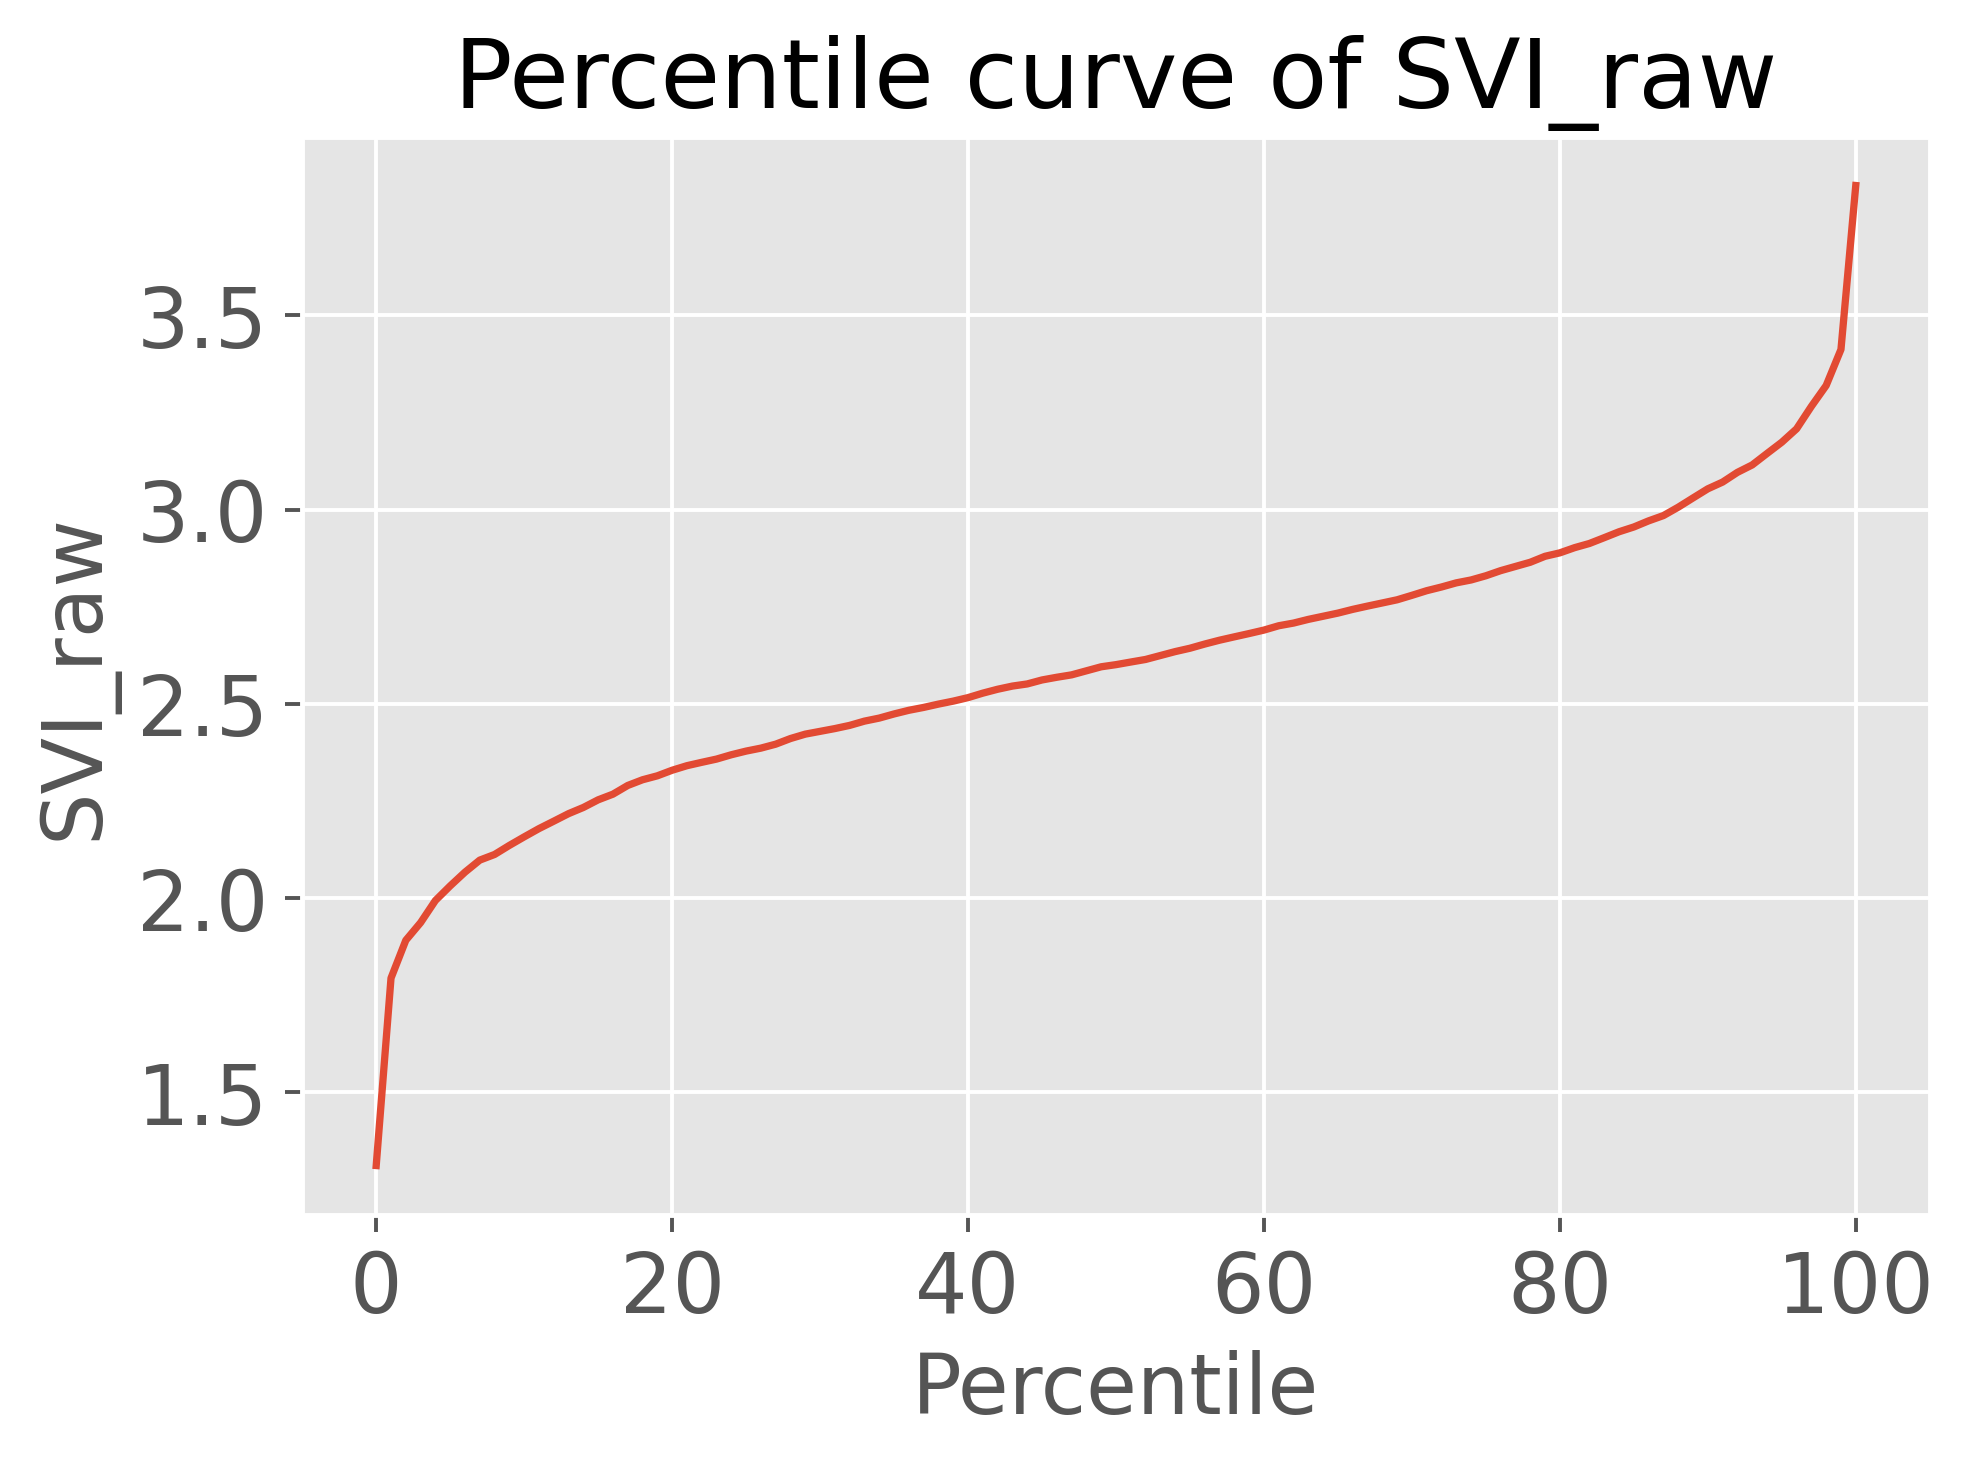

In [49]:
percentiles = np.arange(0, 101, 1)
qs = np.percentile(s, percentiles)
plt.figure(figsize=(6, 4))
plt.plot(percentiles, qs)
plt.xlabel("Percentile")
plt.ylabel("SVI_raw")
plt.title("Percentile curve of SVI_raw")
plt.grid(True)
plt.show()


#### Plotting the SVI Distribution on MAP

In [ ]:
def calculate_svi_method1(are_correlated, individuals_with_trips_df):
    """
    Calculate SVI using weighted average - most interpretable approach
    """
    # Update the dataframe with area names and weights
    are_correlated_weighted = are_correlated.with_columns([
        pl.Series("insee_code", individuals_with_trips_df["CODGEO"].cast(pl.Utf8)),
        pl.Series("AREA_NAME", individuals_with_trips_df["AREA_NAME"]),
        pl.Series("WEIGHT_INDIV", individuals_with_trips_df["WEIGHT_INDIV"].cast(pl.Float64)),
        pl.Series("svi_raw", are_correlated["SVI_raw"].cast(pl.Float64))
    ])

    # Calculate weighted SVI scores by area
    weighted_svi = are_correlated_weighted.group_by(["insee_code", "AREA_NAME"]).agg([
        pl.col("svi_raw").mul(pl.col("WEIGHT_INDIV")).sum().alias("weighted_svi_sum"),
        pl.col("WEIGHT_INDIV").sum().alias("total_weight")
    ]).with_columns([
        (pl.col("weighted_svi_sum") / pl.col("total_weight")).alias("svi_score")
    ])

    # Apply MinMaxScaler to final SVI scores for better interpretability
    min_max_scaler = MinMaxScaler()
    svi_scores_scaled = min_max_scaler.fit_transform(weighted_svi["svi_score"].to_numpy().reshape(-1, 1))

    # Add scaled scores back to dataframe
    final_svi = weighted_svi.with_columns([
        pl.Series("svi_score", svi_scores_scaled.flatten())
    ])

    return final_svi

In [ ]:

from matplotlib.colors import LinearSegmentedColormap


def create_clean_compact_svi_choropleth(svi_data, save_path=None):
    """
    Create clean, compact choropleth map with beautiful box annotations
    but without cluttered district names on the map

    Parameters:
    svi_data (DataFrame): DataFrame with 'insee_code', 'svi_score', and 'AREA_NAME' columns
    save_path (str, optional): Path to save the figure

    Returns:
    GeoDataFrame: Merged geographic maps_data with SVI scores
    """

    # Load Île-de-France communes
    geojson_url = "https://france-geojson.gregoiredavid.fr/repo/communes.geojson"
    communes_gdf = gpd.read_file(geojson_url)

    # Filter for Île-de-France departments
    idf_departments = ['75', '77', '78', '91', '92', '93', '94', '95']
    communes_gdf['dept'] = communes_gdf['code'].str[:2]
    idf_gdf = communes_gdf[communes_gdf['dept'].isin(idf_departments)].copy()

    # Process and merge SVI maps_data
    svi_grouped = svi_data.groupby(['insee_code', 'AREA_NAME'])['svi_score'].mean().reset_index()
    svi_grouped['insee_code'] = svi_grouped['insee_code'].astype(str)
    idf_gdf['code'] = idf_gdf['code'].astype(str)

    map_data = idf_gdf.merge(svi_grouped, left_on='code', right_on='insee_code', how='left')
    map_data['svi_score'] = map_data['svi_score'].fillna(0)

    # Filter to areas with maps_data for focused view
    areas_with_data = map_data[map_data['svi_score'] > 0].copy()

    # Apply ggplot style
    plt.style.use('seaborn-v0_8-whitegrid')

    # Create compact figure with high DPI
    fig, ax = plt.subplots(1, 1, figsize=(14, 10), dpi=300)

    # Set background color for ggplot feel
    fig.patch.set_facecolor('#F8F8F8')
    ax.set_facecolor('#F8F8F8')

    # Calculate percentiles for better color scaling
    svi_values = areas_with_data['svi_score']
    vmin, vmax = svi_values.quantile([0.02, 0.98]) if len(svi_values) > 0 else (0, 1)

    # Create custom colormap with better contrast
    colors = ['#2166AC', '#4393C3', '#92C5DE', '#D1E5F0', '#F7F7F7',
              '#FDBF6F', '#FF7F00', '#E31A1C', '#B10026']
    n_bins = 100
    cmap = LinearSegmentedColormap.from_list('custom', colors, N=n_bins)

    # Plot all areas in light gray first (context)
    map_data.plot(
        ax=ax,
        color='#E8E8E8',
        edgecolor='white',
        linewidth=0.2,
        alpha=0.4
    )

    # Create choropleth for areas with maps_data
    areas_with_data.plot(
        column='svi_score',
        ax=ax,
        cmap=cmap,
        edgecolor='white',
        linewidth=0.3,
        alpha=0.9,
        vmin=vmin,
        vmax=vmax,
        legend=False
    )

    # Add department boundaries with subtle styling
    dept_boundaries = map_data.dissolve(by='dept')
    dept_boundaries.boundary.plot(ax=ax, color='#2C3E50', linewidth=1.0, alpha=0.6)

    # Set view to focus on areas with maps_data (with some padding)
    if len(areas_with_data) > 0:
        bounds = areas_with_data.total_bounds
        padding = 0.03
        ax.set_xlim(bounds[0] - padding, bounds[2] + padding)
        ax.set_ylim(bounds[1] - padding, bounds[3] + padding)

    # Create custom colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, shrink=0.7, aspect=25, pad=0.02)
    cbar.set_label('Social Vulnerability Index (SVI)',
                   fontsize=12, fontweight='bold', labelpad=15)
    cbar.ax.tick_params(labelsize=10)

    # Clean, compact title
    main_title = 'Social Vulnerability Index Distribution'
    subtitle = 'Île-de-France Region'

    ax.text(0.5, 0.96, main_title,
            transform=ax.transAxes, fontsize=16, fontweight='bold',
            ha='center', va='top', color='#2C3E50')
    ax.text(0.5, 0.93, subtitle,
            transform=ax.transAxes, fontsize=11, style='italic',
            ha='center', va='top', color='#5D6D7E')

    # Compact statistical annotations box
    stats_text = (
        f'📊 Dataset Overview\n'
        f'Areas Analyzed: {len(areas_with_data):,}\n'
        f'Mean SVI: {svi_values.mean():.2f}\n'
        f'Median SVI: {svi_values.median():.2f}\n'
        f'Range: {svi_values.min():.1f} - {svi_values.max():.1f}\n'
        f'Std Dev: {svi_values.std():.2f}'
    )

    ax.text(0.02, 0.95, stats_text,
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.95,
                      edgecolor='#BDC3C7', linewidth=1),
            verticalalignment='top',
            fontfamily='monospace')

    # Enhanced top/bottom areas legend with better formatting
    high_svi = areas_with_data.nlargest(6, 'svi_score')
    low_svi = areas_with_data.nsmallest(6, 'svi_score')

    legend_text = (
        f'Highest Vulnerability\n'
        f'{chr(10).join([f"• {row.AREA_NAME[:20]}{"..." if len(row.AREA_NAME) > 20 else ""} ({row.svi_score:.1f})" for _, row in high_svi.iterrows()])}\n\n'
        f'Lowest Vulnerability\n'
        f'{chr(10).join([f"• {row.AREA_NAME[:20]}{"..." if len(row.AREA_NAME) > 20 else ""} ({row.svi_score:.1f})" for _, row in low_svi.iterrows()])}'
    )

    ax.text(0.98, 0.95, legend_text,
            transform=ax.transAxes, fontsize=8,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#ECF0F1', alpha=0.95,
                      edgecolor='#95A5A6', linewidth=1),
            verticalalignment='top', horizontalalignment='right')

    # Compact interpretation guide
    interpretation_text = (
        'Color Scale Interpretation\n'
        'Red: High vulnerability\n'
        'Yellow: Medium vulnerability\n'
        'Blue: Low vulnerability\n'
        '\n'
        'SVI Components:\n'
        'Education levels\n'
        'Mobility resources\n'
        'Demographics\n'
        'Transportation access'
    )

    ax.text(0.02, 0.05, interpretation_text,
            transform=ax.transAxes, fontsize=8,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#E8F6F3', alpha=0.95,
                      edgecolor='#52C41A', linewidth=1),
            verticalalignment='bottom', horizontalalignment='left')

    # Compact methodology note
    methodology_text = (
        'Methodology: SVI computed using PCA-weighted socioeconomic indicators | '
        f'Coverage: {len(areas_with_data) / len(map_data) * 100:.1f}% of Île-de-France communes'
    )

    ax.text(0.5, 0.02, methodology_text,
            transform=ax.transAxes, fontsize=7, style='italic',
            ha='center', va='bottom', color='#7F8C8D',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9))

    # Remove axes for cleaner look
    ax.set_axis_off()

    # Add subtle grid lines for ggplot feel
    ax.grid(True, alpha=0.1, linestyle='-', linewidth=0.3, color='#BDC3C7')

    # Add compact north arrow
    ax.annotate('N', xy=(0.96, 0.88), xytext=(0.96, 0.85),
                xycoords='axes fraction', textcoords='axes fraction',
                fontsize=12, fontweight='bold', ha='center',
                arrowprops=dict(arrowstyle='->', color='#2C3E50', lw=1.5))

    # Tight layout with minimal padding
    plt.tight_layout(pad=0.5)

    # Save with high quality if path provided
    if save_path:
        plt.savefig(save_path, dpi=400, bbox_inches='tight',
                    facecolor='#F8F8F8', edgecolor='none',
                    format='png')
        print(f"Clean compact map saved to {save_path}")

    plt.show()

    # Clean, compact statistics output
    print("\n" + "=" * 60)
    print("📊 SVI DISTRIBUTION ANALYSIS")
    print("=" * 60)
    print(f"🗺️  Areas Analyzed: {len(areas_with_data)} communes")
    print(f"📈 Coverage: {len(areas_with_data) / len(map_data) * 100:.1f}% of Île-de-France")
    print(f"📊 Mean SVI: {svi_values.mean():.2f} ± {svi_values.std():.2f}")
    print(f"📊 Range: {svi_values.min():.1f} - {svi_values.max():.1f}")

    print(f"\n🔴 TOP 5 MOST VULNERABLE AREAS:")
    print("-" * 45)
    for i, (_, row) in enumerate(high_svi.head(5).iterrows(), 1):
        print(f"{i}. {row['AREA_NAME']:25} | {row['svi_score']:5.2f}")

    print(f"\n🔵 TOP 5 LEAST VULNERABLE AREAS:")
    print("-" * 45)
    for i, (_, row) in enumerate(low_svi.head(5).iterrows(), 1):
        print(f"{i}. {row['AREA_NAME']:25} | {row['svi_score']:5.2f}")

    print("=" * 60)

    return areas_with_data


# =============================================================================
# CLEAN COMPACT EXECUTION
# =============================================================================
result_method1 = calculate_svi_method1(are_correlated, individuals_with_trips_df)
svi_data = result_method1.select(['insee_code', 'svi_score', 'AREA_NAME']).to_pandas()

# Create the clean compact map
print("🗺️  Creating Clean Compact SVI Choropleth Map...")
print("⚙️  Features: Beautiful box annotations, clean design, focused view")
print("🎯 Design: Compact layout without cluttered district names")

result = create_clean_compact_svi_choropleth(svi_data, save_path='clean_compact_svi_map.png')

print("\n✅ Clean compact visualization complete!")
print("📊 Beautiful box annotations preserved with cleaner map design")

## Intuitions & Brainstorming

In [ ]:
#1st intuition 1/1+log(age) for ages lower than mean and log(age)-1 for ages above
"""
mean_age = 43
Age 42: 1 / (1 + log(42)) = 1 / (1 + 3.74) = 0.211
Age 44: log(44) - 1 = 3.78 - 1 = 2.78
"""

#2nd idea log(1 + |AGE - μ|) produces u-shaped snooth curve

Saved: relationship_inverse_log.png


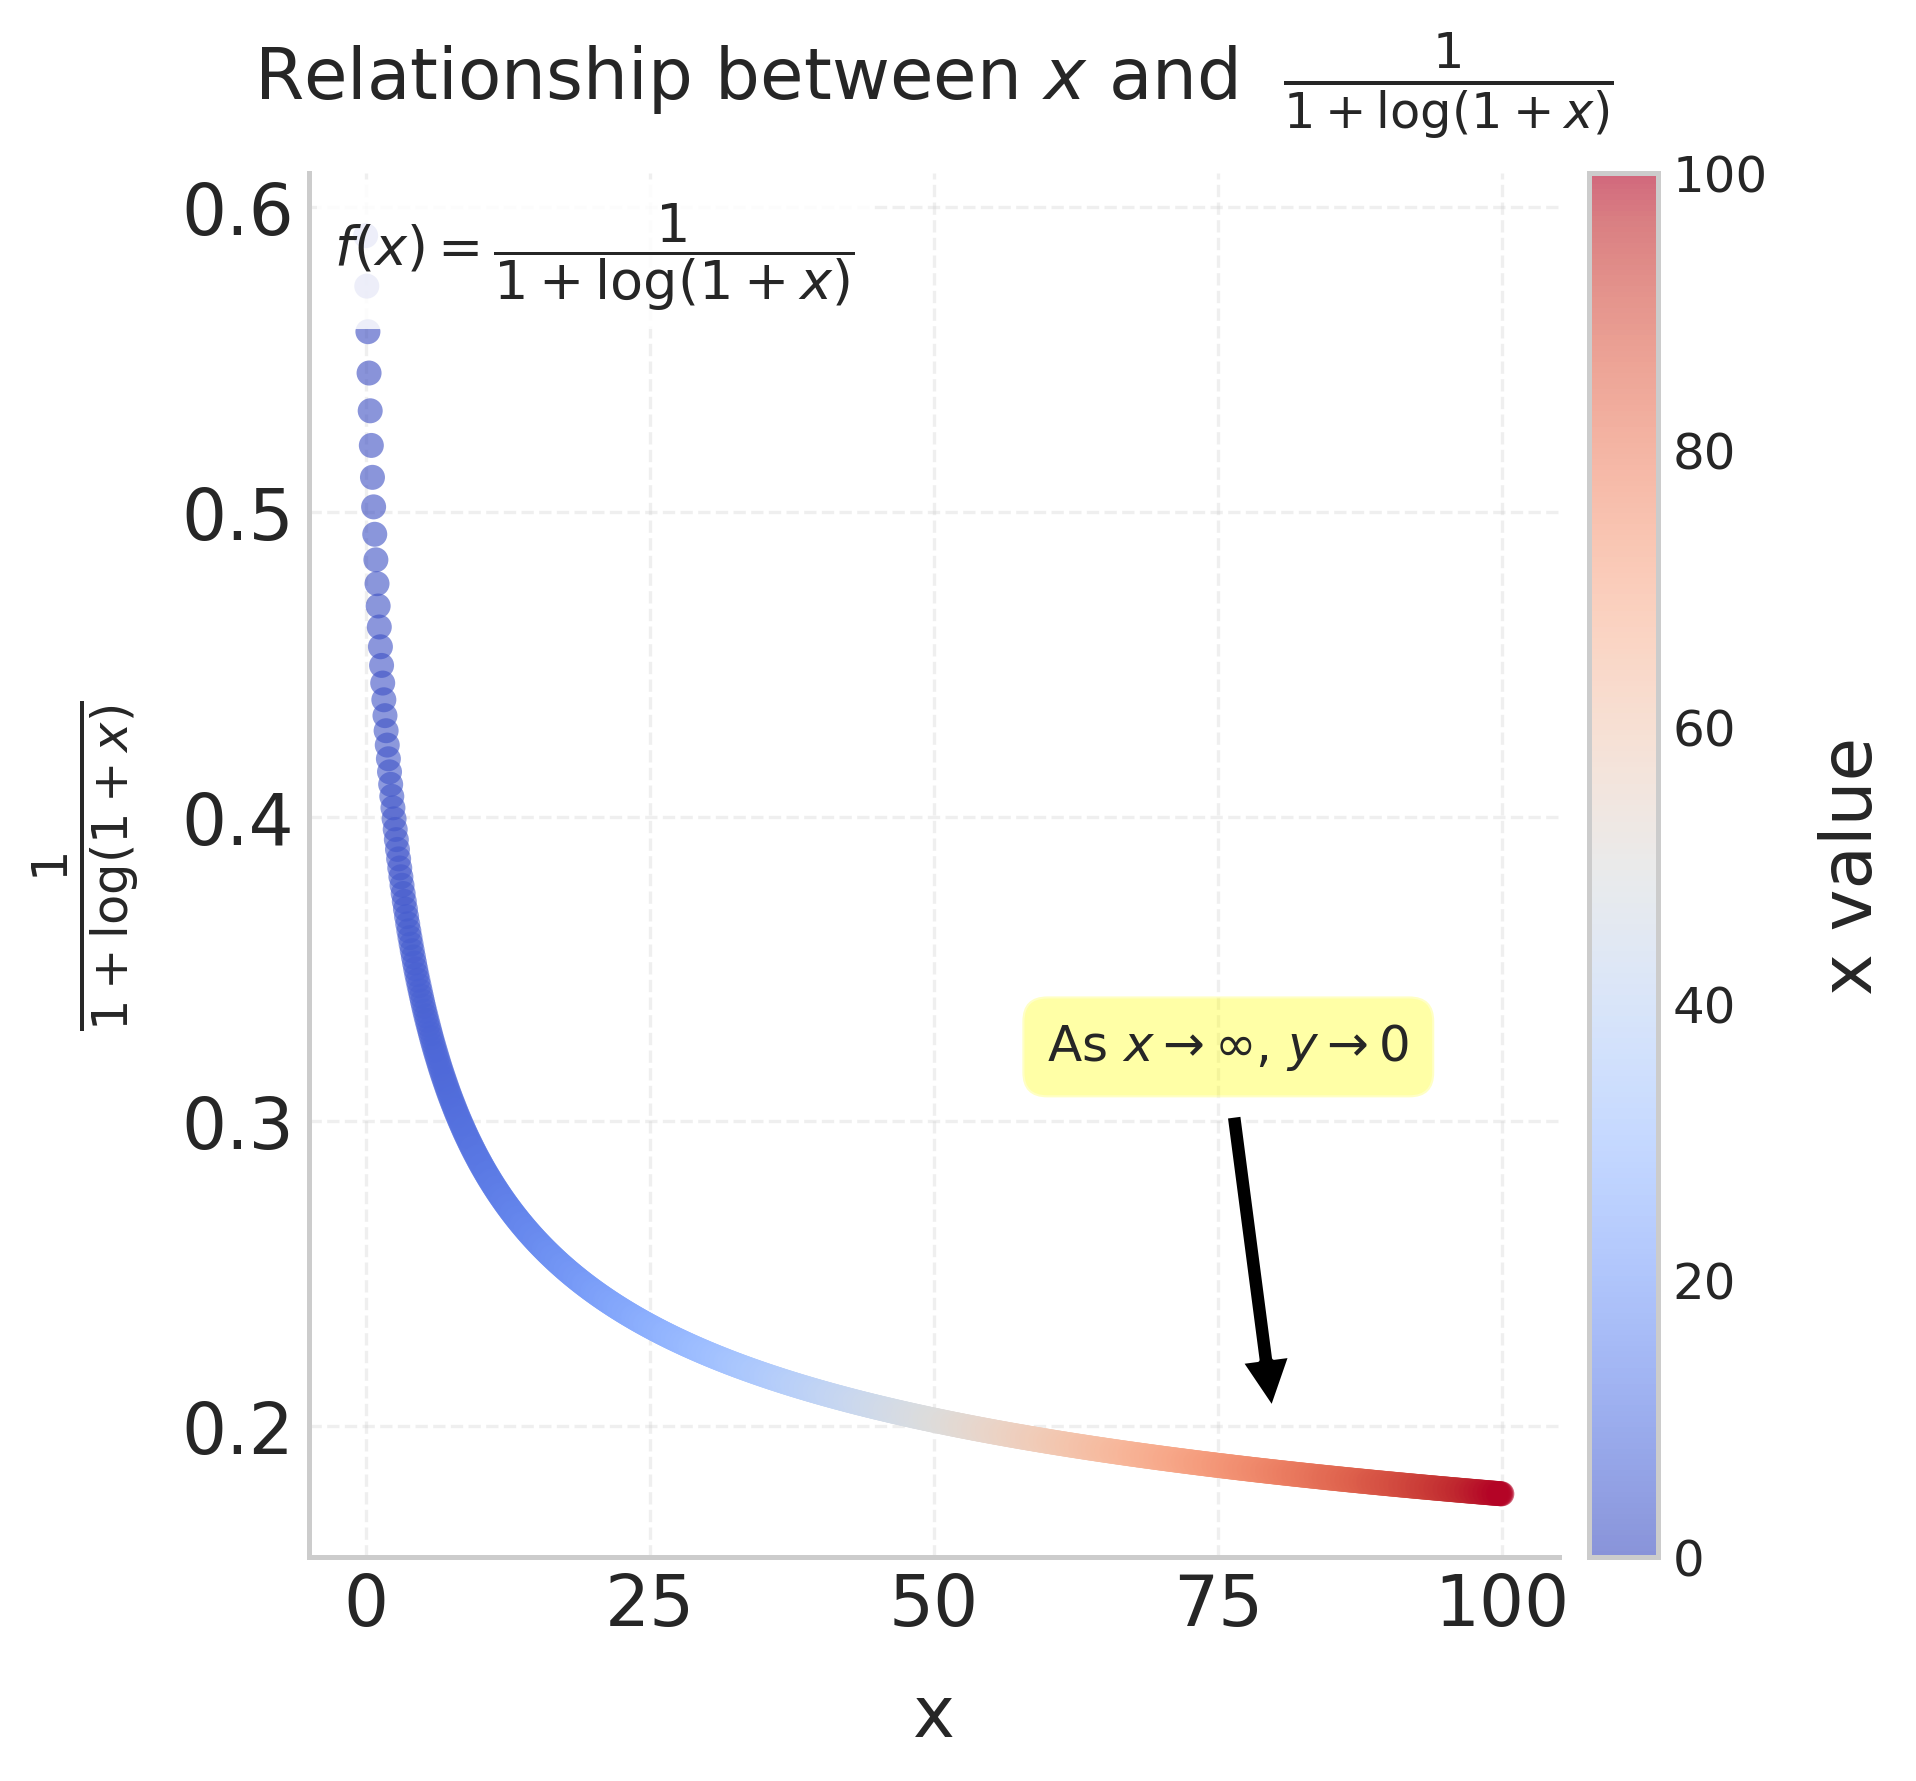

Saved: relationship_log1p.png


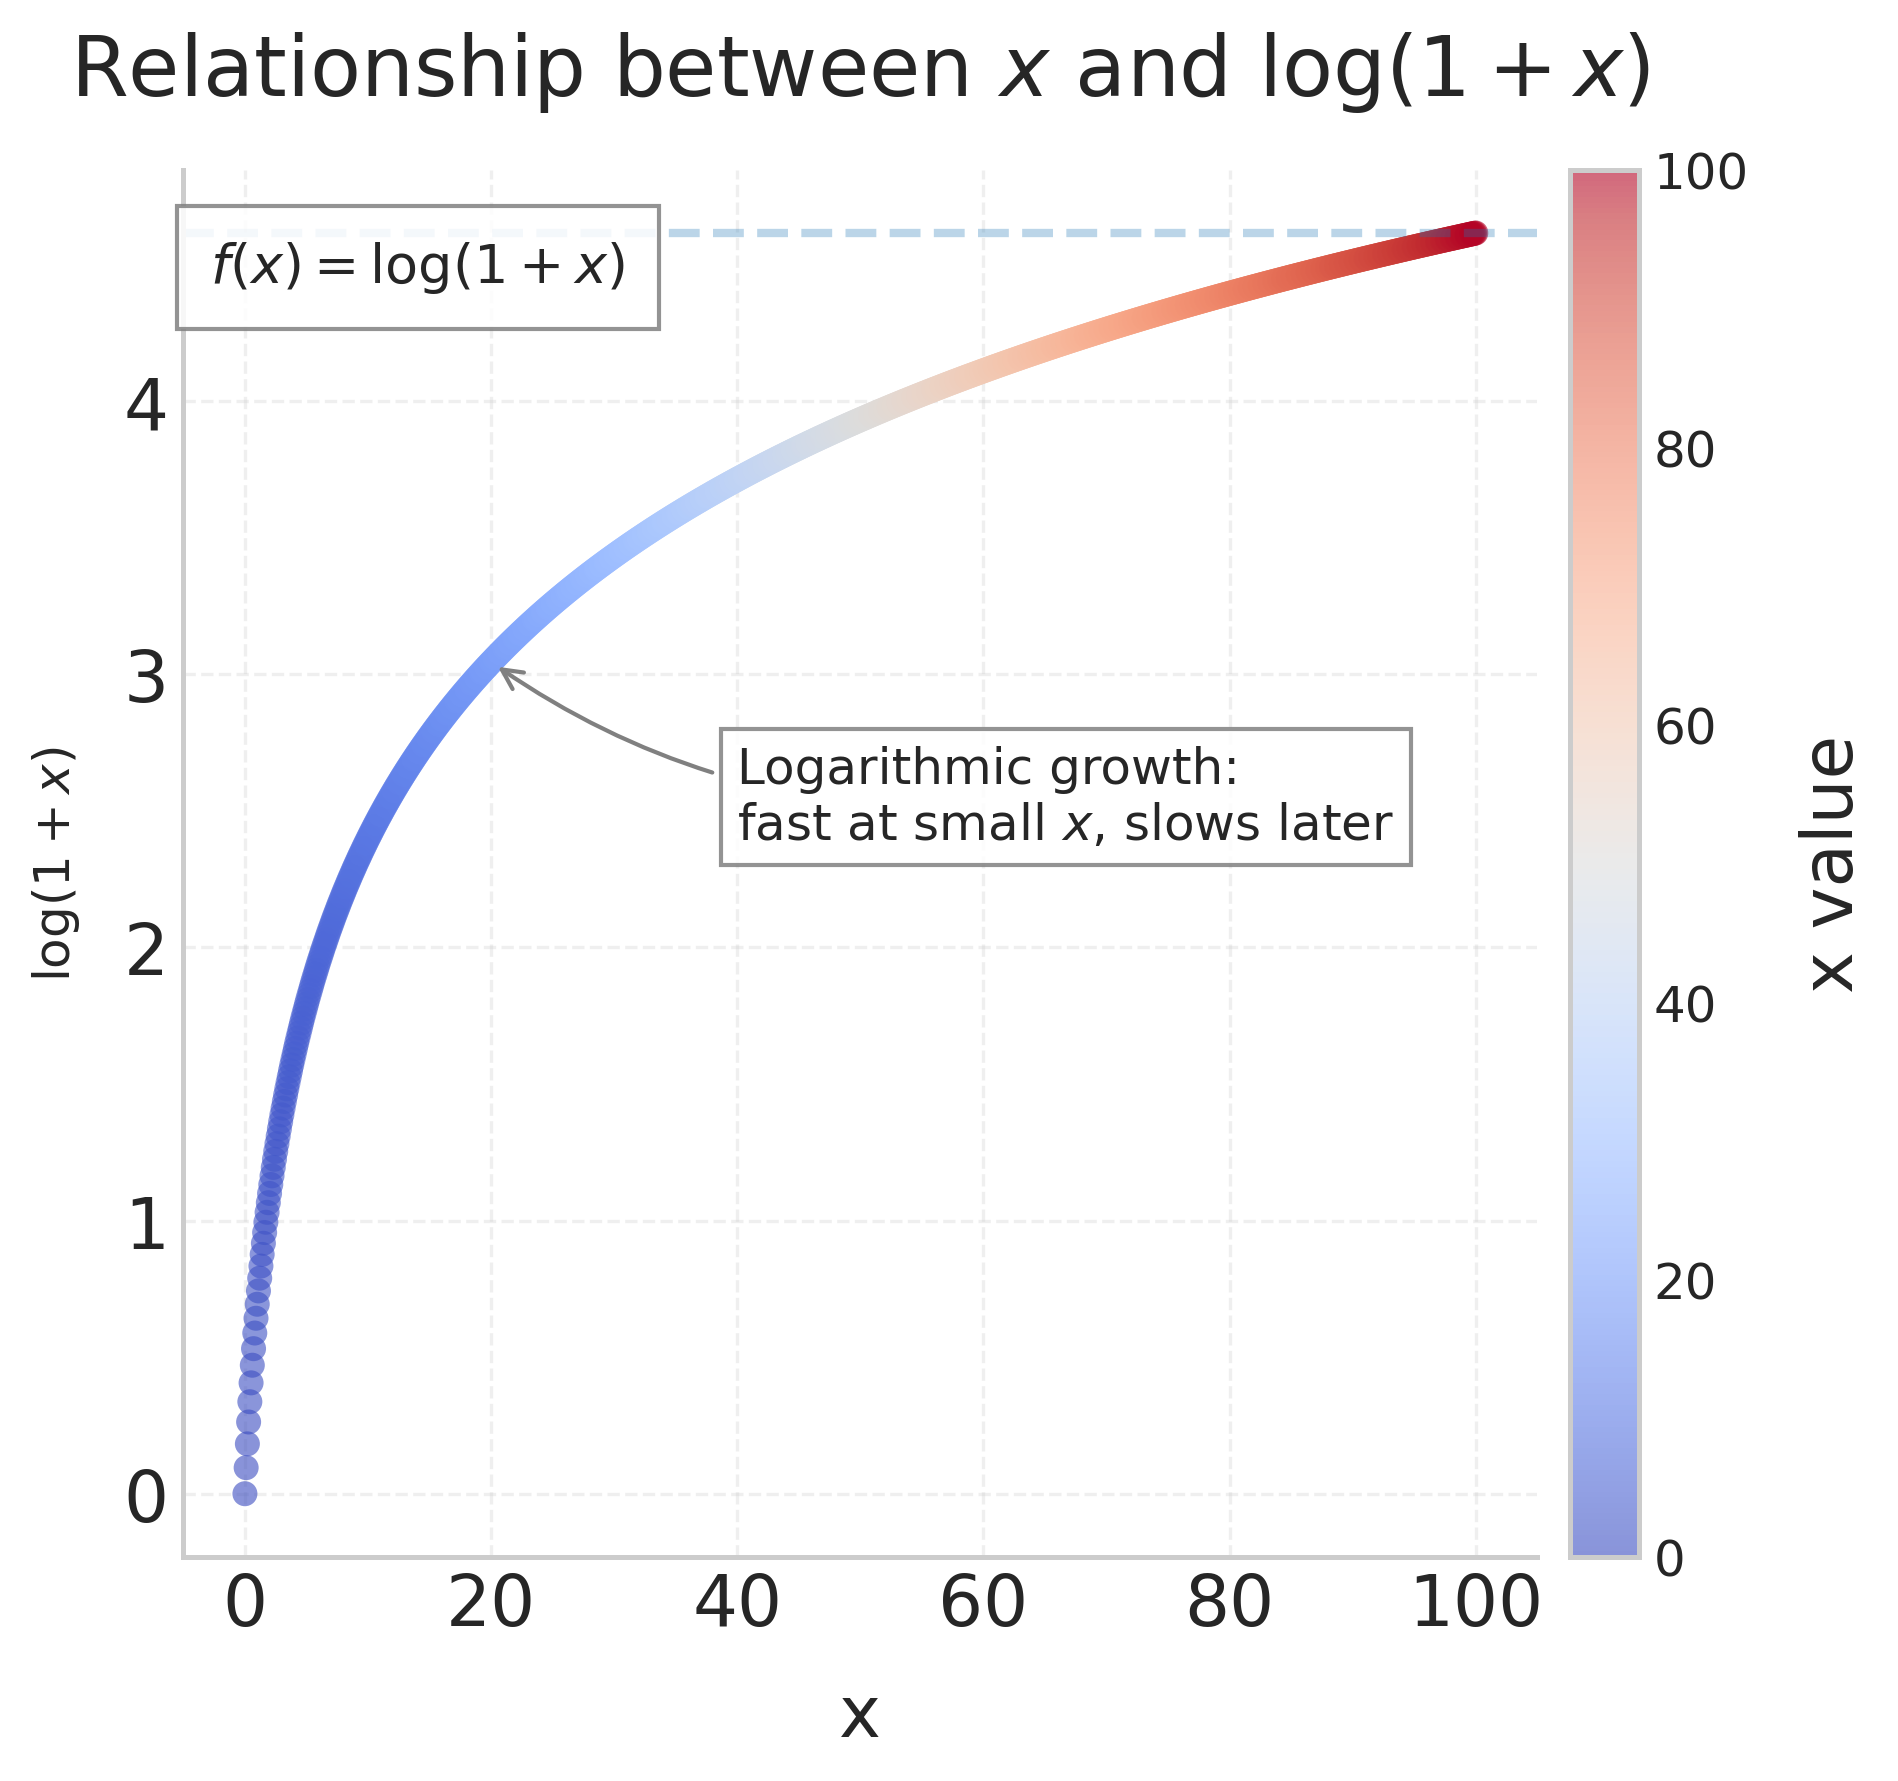

In [17]:
# ---------------------------
# Plot 1: 1 / (1 + log(1 + x))
# ---------------------------
def plot_inverse_log():
    i_s = np.linspace(0, 100, 1000)
    y = 1 / (1 + np.log1p(1 + i_s))  # numerically stable form

    fig, ax = plt.subplots()
    sc = ax.scatter(i_s, y,
                    c=i_s,
                    cmap=CMAP,
                    s=MARKER_SIZE,
                    alpha=ALPHA,
                    edgecolors="none")

    # Colorbar
    cbar = plt.colorbar(sc, ax=ax, pad=0.02)
    cbar.set_label("x value", fontsize=COLORBAR_FONTSIZE, labelpad=12)
    cbar.ax.tick_params(labelsize=COLORBAR_FONTSIZE - 5)

    # Labels & title
    ax.set_title(r"Relationship between $x$ and $\; \frac{1}{1+\log(1+x)}$",
                 fontsize=TITLE_FONTSIZE - 3, pad=18)
    ax.set_xlabel("x", fontsize=BASE_FONTSIZE, labelpad=10)
    ax.set_ylabel(r"$\frac{1}{1+\log(1+x)}$", fontsize=BASE_FONTSIZE, labelpad=10)

    # Grid + ticks
    ax.grid(**GRID_STYLE)
    ax.tick_params(axis="both", which="major", labelsize=TICK_FONTSIZE)

    # Annotation (consistent font & box)
    ax.annotate("As $x \\to \\infty$, $y \\to 0$",
                xy=(80, 0.2),
                xytext=(60, 0.32),
                fontsize=ANNOT_FONTSIZE - 5,
                arrowprops=dict(facecolor="black", shrink=0.05, linewidth=1),
                bbox=dict(boxstyle="round,pad=0.5", fc="yellow", alpha=0.35))

    # Math formula in corner (consistent box / font)
    ax.text(0.02, 0.98, r"$f(x) = \dfrac{1}{1 + \log(1+x)}$",
            transform=ax.transAxes,
            fontsize=MATH_FONTSIZE - 5,
            verticalalignment="top",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.85))

    savefig_standard("relationship_inverse_log.png")
    plt.show()


# ---------------------------
# Plot 2: log(1 + x)
# ---------------------------
def plot_log1p():
    x = np.linspace(0, 100, 1000)
    y = np.log1p(x)

    fig, ax = plt.subplots()
    sc = ax.scatter(x, y,
                    c=x,
                    cmap=CMAP,
                    s=MARKER_SIZE,
                    alpha=ALPHA,
                    edgecolors="none")

    # Colorbar (same style as plot 1)
    cbar = plt.colorbar(sc, ax=ax, pad=0.02)
    cbar.set_label("x value", fontsize=COLORBAR_FONTSIZE, labelpad=12)
    cbar.ax.tick_params(labelsize=COLORBAR_FONTSIZE - 5)

    # Title & labels
    ax.set_title(r"Relationship between $x$ and $\log(1+x)$",
                 fontsize=TITLE_FONTSIZE, pad=18)
    ax.set_xlabel("x", fontsize=BASE_FONTSIZE, labelpad=10)
    ax.set_ylabel(r"$\log(1+x)$", fontsize=BASE_FONTSIZE - 5, labelpad=10)

    # Grid + ticks
    ax.grid(**GRID_STYLE)
    ax.tick_params(axis="both", which="major", labelsize=TICK_FONTSIZE)

    # Annotation (consistent style)
    ax.annotate("Logarithmic growth:\nfast at small $x$, slows later",
                xy=(20, np.log1p(20)),
                xytext=(40, np.log1p(10)),
                fontsize=ANNOT_FONTSIZE - 5,
                bbox=dict(facecolor="white", edgecolor="gray", alpha=0.85),
                arrowprops=dict(arrowstyle="->",
                                connectionstyle="arc3,rad=-.2",
                                color="gray"))

    # Math text
    ax.text(0.02, 0.95, r"$f(x) = \log(1+x)$",
            transform=ax.transAxes,
            fontsize=MATH_FONTSIZE - 5,
            verticalalignment="top",
            bbox=dict(facecolor="white", edgecolor="gray", alpha=0.85, pad=8))

    # Horizontal line to mark value at x=100 (keeps same style/color across figures)
    ax.axhline(y=np.log1p(100), linestyle="--", alpha=0.3)
    # ax.text(80, np.log1p(100) - 0.1, "Reference: log(101)",
    #         fontsize=ANNOT_FONTSIZE-5, color="red")

    savefig_standard("relationship_log1p.png")
    plt.show()


# ---------------------------
# Run both plots
# ---------------------------
if __name__ == "__main__":
    import numpy as np

    plot_inverse_log()
    plot_log1p()


In [ ]:
"""Indicator Group	Variable(s) from Dataset	What It Measures (Proxy for...)
Physical Capacity	PMR, AGE	Direct physical barriers to mobility
Household Resources	NB_CAR, DRIVING_LICENCE, TWO_WHEELER etc.	Access to private, independent transport options
Household Constraints	NBPERS_HOUSE, NB_10, etc.	Presence of dependents complicating evacuation
Socio-Economic Status	DIPLOMA, PRO_CAT	Income, job flexibility, information access
System Dependency	NAVIGO_SUB, etc.	Reliance on public systems that might fail
"""

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pynsee.geodata import get_geodata, get_geodata_list
import os

os.environ['sirene_key'] = '8443bcd3-ebf5-4a54-83bc-d3ebf51a546f'

# Step 1: Explore available geodata and find commune identifiers
print("Available geodata types:")
geodata_list = get_geodata_list()

# Find commune-related identifiers
commune_identifiers = []
for _, row in geodata_list.iterrows():
    if 'commune' in row['Identifier'].lower():
        commune_identifiers.append(row['Identifier'])

print(f"\nFound {len(commune_identifiers)} commune identifiers:")
for identifier in commune_identifiers:
    print(f"  - {identifier}")


# Helper function to find the best column name
def find_column_by_pattern(df, patterns):
    """Find a column name that matches any of the given patterns"""
    for col in df.columns:
        for pattern in patterns:
            if pattern.lower() in col.lower():
                return col
    return None


# Step 2: Load your SVI maps_data (replace with your actual maps_data loading)
# Assuming your maps_data has columns: 'insee_code' and 'svi_score'
# svi_data = pd.read_csv('your_svi_data.csv')  # Replace with your actual file

# For demonstration, let's create sample maps_data
# In practice, replace this with your actual maps_data loading
sample_insee_codes = ['75001', '75002', '75003', '92001', '92002', '93001', '94001', '95001']
sample_svi_scores = [150, 200, 180, 220, 190, 250, 210, 170]
svi_data = pd.DataFrame({
    'insee_code': sample_insee_codes,
    'svi_score': sample_svi_scores
})

# Step 3: Group by INSEE codes and sum SVI scores
# If you have multiple rows per INSEE code, this will aggregate them
svi_grouped = svi_data.groupby('insee_code')['svi_score'].sum().reset_index()
print(f"Grouped SVI maps_data shape: {svi_grouped.shape}")
print(svi_grouped.head())

# Step 4: Get geographic maps_data for Île-de-France
# From the geodata list, we need to use the correct identifier
print("\nLooking for commune maps_data in geodata list...")

# Get all communes in France first (we'll filter for Île-de-France later)
# Using the identifier from the geodata list
try:
    # Try the most recent commune maps_data
    idf_geodata = get_geodata('ADMINEXPRESS-COG.LATEST:commune')
    print(f"\nGeodata shape: {idf_geodata.shape}")
    print(f"Columns: {idf_geodata.columns.tolist()}")

    # Display sample of geodata
    print("\nSample of geodata:")
    print(idf_geodata.head())

    # Filter for Île-de-France (region code 11)
    # The region code is usually in a column like 'reg' or 'region'
    region_col = None
    for col in idf_geodata.columns:
        if 'reg' in col.lower():
            region_col = col
            break

    if region_col:
        print(f"\nUsing region column: {region_col}")
        print(f"Unique region values: {sorted(idf_geodata[region_col].unique())}")

        # Filter for Île-de-France (region code 11)
        idf_geodata = idf_geodata[idf_geodata[region_col] == '11'].copy()
        print(f"Filtered maps_data shape for Île-de-France: {idf_geodata.shape}")
    else:
        print("Could not find region column, using all communes")

except Exception as e:
    print(f"Error loading geodata: {e}")
    # Try alternative identifier
    try:
        print("Trying alternative identifier...")
        idf_geodata = get_geodata('ADMINEXPRESS-COG.2017:commune')
        print(f"Alternative geodata shape: {idf_geodata.shape}")
        print(f"Columns: {idf_geodata.columns.tolist()}")

        # Filter for Île-de-France if region column exists
        region_col = None
        for col in idf_geodata.columns:
            if 'reg' in col.lower():
                region_col = col
                break

        if region_col:
            idf_geodata = idf_geodata[idf_geodata[region_col] == '11'].copy()
            print(f"Filtered maps_data shape for Île-de-France: {idf_geodata.shape}")

    except Exception as e2:
        print(f"Alternative approach also failed: {e2}")
        print("Please check available identifiers in the geodata list")

# Step 5: Merge SVI maps_data with geographic maps_data
# Find the INSEE code column using multiple possible patterns
insee_patterns = ['insee', 'com', 'code_insee', 'depcom', 'insee_com']
insee_col = find_column_by_pattern(idf_geodata, insee_patterns)

if insee_col:
    print(f"\nUsing INSEE column: {insee_col}")
    print(f"Sample INSEE codes: {idf_geodata[insee_col].head().tolist()}")

    # Ensure INSEE codes are strings and properly formatted
    idf_geodata[insee_col] = idf_geodata[insee_col].astype(str)
    svi_grouped['insee_code'] = svi_grouped['insee_code'].astype(str)

    # Merge the maps_data
    map_data = idf_geodata.merge(
        svi_grouped,
        left_on=insee_col,
        right_on='insee_code',
        how='left'
    )

    # Fill NaN values with 0 for areas without SVI maps_data
    map_data['svi_score'] = map_data['svi_score'].fillna(0)

    print(f"Merged maps_data shape: {map_data.shape}")
    print(f"Areas with SVI maps_data: {(map_data['svi_score'] > 0).sum()}")

    # Show which INSEE codes from your maps_data were matched
    matched_codes = map_data[map_data['svi_score'] > 0]['insee_code'].unique()
    unmatched_codes = set(svi_grouped['insee_code']) - set(matched_codes)

    print(f"Matched INSEE codes: {sorted(matched_codes)}")
    if unmatched_codes:
        print(f"Unmatched INSEE codes: {sorted(unmatched_codes)}")

else:
    print("Could not find INSEE code column in geodata")
    print("Available columns:", idf_geodata.columns.tolist())

    # If we can't find the INSEE column, show some sample maps_data to help debug
    print("\nSample of geodata to help identify the right column:")
    print(idf_geodata.head())

    # Exit early if we can't find the column
    print("Please check the column names and update the code accordingly.")
    exit()

# Step 6: Create the choropleth map
if 'map_data' in locals() and not map_data.empty:
    fig, ax = plt.subplots(1, 1, figsize=(12, 10))

    # Create the choropleth map
    map_data.plot(
        column='svi_score',
        ax=ax,
        legend=True,
        cmap='YlOrRd',  # Color map (yellow to red)
        edgecolor='black',
        linewidth=0.1,
        legend_kwds={
            'label': 'SVI Score',
            'orientation': 'vertical',
            'shrink': 0.6
        }
    )

    # Customize the map
    ax.set_title('SVI Scores by District in Île-de-France', fontsize=16, fontweight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

    # Remove axis ticks for cleaner look
    ax.tick_params(axis='both', which='major', labelsize=8)

    # Add grid
    ax.grid(True, alpha=0.3)

    # Tight layout
    plt.tight_layout()

    # Show the map
    plt.show()

    # Step 7: Print summary statistics
    print(f"\nSVI Score Statistics:")
    print(f"Mean: {map_data['svi_score'].mean():.2f}")
    print(f"Median: {map_data['svi_score'].median():.2f}")
    print(f"Min: {map_data['svi_score'].min():.2f}")
    print(f"Max: {map_data['svi_score'].max():.2f}")
    print(f"Standard deviation: {map_data['svi_score'].std():.2f}")

    # Optional: Save the map
    # plt.savefig('idf_svi_map.png', dpi=300, bbox_inches='tight')

else:
    print("Cannot create map - maps_data merging failed or no maps_data available.")

In [ ]:


# Optional: Interactive map with Folium (uncomment to use)
"""
import folium

def create_interactive_map(map_data):
    # Create base map centered on Paris
    m = folium.Map(location=[48.8566, 2.3522], zoom_start=10)

    # Add choropleth layer
    folium.Choropleth(
        geo_data=map_data,
        maps_data=map_data,
        columns=['code', 'svi_score'],
        key_on='feature.properties.code',
        fill_color='YlOrRd',
        fill_opacity=0.7,
        line_opacity=0.2,
        legend_name='SVI Score'
    ).add_to(m)

    # Add tooltips
    folium.features.GeoJsonTooltip(
        fields=['nom', 'code', 'svi_score'],
        aliases=['Commune:', 'INSEE Code:', 'SVI Score:'],
        localize=True
    ).add_to(m)

    return m

# Create interactive map
# interactive_map = create_interactive_map(result)
# interactive_map.save('idf_svi_interactive_map.html')
"""